In [151]:
!git lfs install


Updated git hooks.
Git LFS initialized.


In [152]:
!git lfs track "*.pth"
!git lfs track "*.joblib"
!git lfs track "*.json"


Tracking "*.pth"
Tracking "*.joblib"
Tracking "*.json"


In [ ]:
from IPython.display import HTML

HTML('''
<style>
.output pre {
  font-size: 19px;  /* change this number to make it bigger or smaller */
}
</style>
''')

!git add .
!git commit -m "Your commit message here"

#push
token = "####"
username = "your_github_username"
repo = "IowaDOT_IRI"

!git remote set-url origin https://{token}@github.com/Kunle-xy/IowaDOT_IRI.git
!git push origin main


In [ ]:
!git push


hint: The '.git/hooks/pre-push' hook was ignored because it's not set as executable.
hint: You can disable this warning with `git config advice.ignoredHook false`.
Enumerating objects: 112, done.
Counting objects: 100% (112/112), done.
Delta compression using up to 32 threads
Compressing objects: 100% (86/86), done.


# GITHUB SETTING

In [1]:
!git clone https://github.com/Kunle-xy/IowaDOT_IRI.git

Cloning into 'IowaDOT_IRI'...
remote: Enumerating objects: 188, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 188 (delta 67), reused 73 (delta 22), pack-reused 65 (from 1)
Receiving objects: 100% (188/188), 82.92 MiB | 14.56 MiB/s, done.
Resolving deltas: 100% (93/93), done.
Updating files: 100% (82/82), done.


In [ ]:
# ⚠️ DO NOT hardcode token in plain text!
from getpass import getpass
import os

# Prompt safely for GitHub token
token = getpass('Enter your GitHub token: ')

# Clone the private repo
os.system(f"git clone https://github.com/Kunle-xy/IowaDOT_IRI.git")




Enter your GitHub token: ··········


32768

In [3]:
%cd /content/IowaDOT_IRI

/content/IowaDOT_IRI


In [ ]:
!ls /content/IowaDOT_IRI


 2-28-2025.xml	      dataframe_drop.csv       processed_07_21
 APP		      dataframe.parquet        scaled_data.csv
 Bucket_131088.xlsx   FINAL_DATASET_2.csv     'Time_series_2 copy.ipynb'
 Bucket_131089.xlsx   FINAL_DATASET.csv        Time_series_2.ipynb
 Bucket_131276.xlsx   Final_Dataset_Drop.csv   Time_series.ipynb
 Bucket_134704.xlsx   models
 D_ANN_model.pth      processed


In [26]:
!git config --global user.name "Kunle-xy"
!git config --global user.email "oguntoye@iastate.edu"


In [ ]:
!git add .
!git commit -m "Your commit message here"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


# MAIN STARTS HERE

## Data except cliamte

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

### AC Layers

In [ ]:
excel_file = 'Bucket_131276.xlsx'
table_name = 'TST_L05B'  # Change this to your desired table

#read excel file with sheet name
df = pd.read_excel(excel_file, sheet_name='TST_L05B')


# Display the DataFrame
print(f"Data from table '{table_name}':")

Data from table 'TST_L05B':


In [ ]:
df.LAYER_TYPE_EXP.value_counts()

,count
LAYER_TYPE_EXP,
Asphalt concrete layer,12194
Subgrade (untreated),3994
Unbound (granular) base,2433
Unbound (granular) subbase,1829
Bound (treated) base,1717
Bound (treated) subbase,628
Engineering Fabric,142


In [ ]:
df.head()

,STATE_CODE,STATE_CODE_EXP,SHRP_ID,CONSTRUCTION_NO,LAYER_NO,PROJECT_LAYER_CODE,DESCRIPTION,DESCRIPTION_EXP,LAYER_TYPE,LAYER_TYPE_EXP,...,LAYER_COMMENT1,LAYER_COMMENT1_EXP,LAYER_COMMENT2,LAYER_COMMENT2_EXP,LAYER_COMMENT3,LAYER_COMMENT3_EXP,COMMENT_NOTE,INV_LAYER_NO,INV_LAYER_NO_2,RECORD_STATUS
0,1,Alabama,0101,1,4,J,3,Original Surface Layer,AC,Asphalt concrete layer,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
1,1,Alabama,0101,1,1,A,7,Subgrade,SS,Subgrade (untreated),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
2,1,Alabama,0101,1,2,E,5,Base Layer,GB,Unbound (granular) base,...,Z,Other (Enter description in COMMENT_NOTE field.),NaN,NaN,NaN,NaN,FIELD SURVEY DATA,NaN,NaN,E
3,1,Alabama,0101,1,3,I,4,AC Layer Below Surface (Binder Course),AC,Asphalt concrete layer,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E
4,1,Alabama,0102,1,4,J,3,Original Surface Layer,AC,Asphalt concrete layer,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,E


In [ ]:
# Set REPR_THICKNESS to 0 where LAYER_TYPE is 'SS'
df.loc[df['LAYER_TYPE'] == 'SS', 'REPR_THICKNESS'] = 0

# Convert REPR_THICKNESS to float
df['REPR_THICKNESS'] = df['REPR_THICKNESS'].astype(float)

# Describe REPR_THICKNESS where LAYER_TYPE is 'SS'
description = df[df['LAYER_TYPE'] == 'SS']['REPR_THICKNESS'].describe()

description



,REPR_THICKNESS
count,3994.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [ ]:
df = df[['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO', 'LAYER_TYPE', 'REPR_THICKNESS', 'MATL_CODE_EXP', 'LAYER_NO' ]]

#fill na with 0
# df.fillna(0, inplace=True)

#rather drop the ones with na
df.dropna(inplace=True)
ef = df.copy()

len(ef)

22937

In [ ]:
ef['LAYER_TYPE'].unique()
test = ef.groupby(['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO', 'LAYER_TYPE'], as_index=False)['REPR_THICKNESS'].sum()

In [ ]:
test[(test['SHRP_ID'] == '0563') & (test['CONSTRUCTION_NO']==3) & (test['STATE_CODE']==1)]

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,LAYER_TYPE,REPR_THICKNESS
139,1,0563,3,AC,99.0
140,1,0563,3,GB,279.4
141,1,0563,3,GS,152.4
142,1,0563,3,SS,0.0


In [ ]:
tmp = test.groupby(['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO'], as_index=False).agg({'LAYER_TYPE': list})

In [ ]:
tmp['AC/NOT'] = tmp['LAYER_TYPE'].apply(lambda x: True if 'AC' in x else False)
tmp['Eng_Fab'] = tmp['LAYER_TYPE'].apply(lambda x: True if 'EF' in x else False)
tmp['Treated_Base'] = tmp['LAYER_TYPE'].apply(lambda x: True if 'TB' in x else False)
tmp['Treated_Subbase'] = tmp['LAYER_TYPE'].apply(lambda x: True if 'TS' in x else False)

In [ ]:
test_df = test.merge(tmp, on = ['STATE_CODE',	'SHRP_ID',	'CONSTRUCTION_NO'], how= 'left')

In [ ]:
# test_df.isna().sum()
# test_df
H_AC = test_df[test_df['LAYER_TYPE_x']=="AC"].reset_index(drop=True)
H_AC.rename(columns={
    'REPR_THICKNESS': 'H_AC'
}, inplace=True)

#drop layer_type col
H_AC.drop(columns=["LAYER_TYPE_x", "LAYER_TYPE_y", "AC/NOT"], inplace=True)
# H_AC

In [ ]:
H_AC.Treated_Base.value_counts()

,count
Treated_Base,
False,2422
True,1572


In [ ]:
H_TOT = df.groupby(['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO'], as_index=False)['REPR_THICKNESS'].sum()
H_TOT.rename(columns={
    'REPR_THICKNESS': 'H_TOT'
}, inplace=True)

In [ ]:
H_TOT['H_TOT'].describe()
H_TOT.head()

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,H_TOT
0,1,0101,1,388.7
1,1,0102,1,411.5
2,1,0102,2,411.5
3,1,0103,1,294.7
4,1,0104,1,470.0


In [ ]:
layers = H_AC.merge(H_TOT, on=['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO'])

In [ ]:
df = df.sort_values(by=['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO', 'LAYER_NO'], ascending=[True, True, True, False]).reset_index(drop=True)

In [ ]:
df.head()

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,LAYER_TYPE,REPR_THICKNESS,MATL_CODE_EXP,LAYER_NO
0,1,0101,1,AC,30.5,"Hot Mixed, Hot Laid AC, Dense Graded",4
1,1,0101,1,AC,157.5,"Hot Mixed, Hot Laid AC, Dense Graded",3
2,1,0101,1,GB,200.7,Crushed Stone,2
3,1,0101,1,SS,0.0,Fine-Grained Soils: Sandy Silt,1
4,1,0102,1,AC,35.6,"Hot Mixed, Hot Laid AC, Dense Graded",4


In [ ]:
layers[(layers['SHRP_ID']=='0107') &(layers['CONSTRUCTION_NO']==3)]
layers[(layers['SHRP_ID'] == '0502')  & (layers['STATE_CODE']==1)]

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT
17,1,0502,1,88.9,False,False,False,505.5
18,1,0502,2,137.2,False,False,False,553.8


In [ ]:
def added_thickness(row):
    data = layers[(layers['SHRP_ID'] == row['SHRP_ID'])
               &
              (layers['STATE_CODE'] == row['STATE_CODE'])]
    if row['CONSTRUCTION_NO'] > 1:
        #find previous construction number in data
        prev = row['CONSTRUCTION_NO'] - 1
        #find previous total thickness
        H_tot_prev = data[data.CONSTRUCTION_NO == prev]['H_TOT'].values[0]

        H_tot = row['H_TOT']
        added_thickness = H_tot - H_tot_prev

        #use 2dp
        return round(added_thickness, 3)
        # return added_thickness
    else:
        return 0

layers['Added_Thickness'] = layers.apply(added_thickness, axis=1)

In [ ]:
layers.to_csv('processed_07_21/TST_L05B_PROCESSED', index=False)

### Maintenance

In [ ]:
table_name = 'EXPERIMENT_SECTION'

excel_file = 'Bucket_131276.xlsx'
df = pd.read_excel(excel_file, sheet_name=table_name)

# Display the DataFrame
print(f"Data from table '{table_name}':")
df.head()

Data from table 'EXPERIMENT_SECTION':


,STATE_CODE,STATE_CODE_EXP,SHRP_ID,CONSTRUCTION_NO,CN_ASSIGN_DATE,CN_CHANGE_REASON,CN_CHANGE_REASON_EXP,RECORD_STATUS,GPS_SPS,GPS_SPS_EXP,...,DEASSIGN_DATE,SEAS_ID,SUPPLEMENTAL,EXP_SECT_RS,BASIC_INFO_RS,PAV_STRUCT_RS,TRAFFIC_RS,CLIMATIC_RS,PAVEMENT_FAMILY,PAVEMENT_FAMILY_EXP
0,1,Alabama,0101,1,1991-04-30,NaN,NaN,E,S,Specific Pavement Studies,...,2005-06-15,A,NaN,E,E,E,E,E,ACUB,Asphalt concrete over unbound base/subgrade
1,1,Alabama,0102,2,2003-04-17,"24,27",Full Depth Patch of AC Pavement (removing dama...,E,S,Specific Pavement Studies,...,2005-06-15,NaN,NaN,E,E,E,E,E,ACUB,Asphalt concrete over unbound base/subgrade
2,1,Alabama,0102,1,1991-04-30,NaN,NaN,E,S,Specific Pavement Studies,...,2005-06-15,B,NaN,E,E,E,E,E,ACUB,Asphalt concrete over unbound base/subgrade
3,1,Alabama,0103,1,1991-04-30,NaN,NaN,E,S,Specific Pavement Studies,...,2005-06-15,NaN,NaN,E,E,E,E,E,ACTB,Asphalt concrete over cement/lime treated base...
4,1,Alabama,0104,1,1991-04-30,NaN,NaN,E,S,Specific Pavement Studies,...,2005-06-15,NaN,NaN,E,E,E,E,E,ACTB,Asphalt concrete over cement/lime treated base...


In [ ]:
df[(df.STATE_CODE == 10) & (df.SHRP_ID == '0107')]

,STATE_CODE,STATE_CODE_EXP,SHRP_ID,CONSTRUCTION_NO,CN_ASSIGN_DATE,CN_CHANGE_REASON,CN_CHANGE_REASON_EXP,RECORD_STATUS,GPS_SPS,GPS_SPS_EXP,...,DEASSIGN_DATE,SEAS_ID,SUPPLEMENTAL,EXP_SECT_RS,BASIC_INFO_RS,PAV_STRUCT_RS,TRAFFIC_RS,CLIMATIC_RS,PAVEMENT_FAMILY,PAVEMENT_FAMILY_EXP
746,10,Delaware,0107,2,1996-09-22,19,Asphalt Concrete Overlay,E,G,General Pavement Studies,...,2008-05-01,NaN,NaN,E,E,E,NaN,E,ACATB,Asphalt concrete over asphalt treated base/sub...
747,10,Delaware,0107,1,1992-01-01,NaN,NaN,E,S,Specific Pavement Studies,...,1996-09-22,NaN,NaN,E,E,E,E,E,ACATB,Asphalt concrete over asphalt treated base/sub...


In [ ]:
test = df[['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO', 'CN_ASSIGN_DATE', 'CN_CHANGE_REASON', 'CN_CHANGE_REASON_EXP' ]]
test = test.dropna()

#rename CN_CHANGE_REASON_EXP to Maintenance
test.rename(columns={
    'CN_CHANGE_REASON_EXP': 'MAINTENANCE'
}, inplace=True)

test.head()
print(len(test))

2572


In [ ]:
test.head()

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,CN_ASSIGN_DATE,CN_CHANGE_REASON,MAINTENANCE
1,1,0102,2,2003-04-17,"24,27",Full Depth Patch of AC Pavement (removing dama...
8,1,0107,2,2001-02-07,22,Manual Premix Spot Patch (hand spreading and c...
18,1,0502,2,1991-12-19,43,Hot-Mix Recycled Asphalt Concrete Overlay
20,1,0503,2,1991-12-16,"43,10","AC Shoulder Restoration, Hot-Mix Recycled Asph..."
22,1,0504,2,1991-12-10,"19,10","AC Shoulder Restoration, Asphalt Concrete Overlay"


In [ ]:
unique_numbers = set()
df["CN_CHANGE_REASON"].dropna().str.split(",").apply(unique_numbers.update)

# Convert to sorted list (optional)
unique_numbers = sorted(map(int, unique_numbers))

In [ ]:
print(len(unique_numbers))

table_name = 'Codes Reference'
excel_file = 'Bucket_131276.xlsx'
code = pd.read_excel(excel_file, sheet_name=table_name)
#read code refernces
# code = pd.read_excel('Codes_Reference.xlsx')
fig = code[code.CODETYPE=='MAINT_WORK']
# only select fig wwithCODE in unique numbers
#
#conver fig.CODE to int
fig.CODE = fig.CODE.astype(int)

fig[fig.CODE.isin(unique_numbers)].to_csv('MAINT_WORK.csv', index=False)

33


/tmp/ipython-input-17-216019885.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fig.CODE = fig.CODE.astype(int)


In [ ]:
test['CN_ASSIGN_DATE'] = pd.to_datetime(test['CN_ASSIGN_DATE'])
#conver CONST to int
test['CONSTRUCTION_NO'] = test['CONSTRUCTION_NO'].astype(int)

test = test.sort_values(by=['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO', 'CN_ASSIGN_DATE']).reset_index(drop=True)

In [ ]:
test.head()


,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,CN_ASSIGN_DATE,CN_CHANGE_REASON,MAINTENANCE
0,1,0102,2,2003-04-17,"24,27",Full Depth Patch of AC Pavement (removing dama...
1,1,0107,2,2001-02-07,22,Manual Premix Spot Patch (hand spreading and c...
2,1,0502,2,1991-12-19,43,Hot-Mix Recycled Asphalt Concrete Overlay
3,1,0503,2,1991-12-16,"43,10","AC Shoulder Restoration, Hot-Mix Recycled Asph..."
4,1,0504,2,1991-12-10,"19,10","AC Shoulder Restoration, Asphalt Concrete Overlay"


In [ ]:
test['MAINTENANCE_YEAR'] = test['CN_ASSIGN_DATE'].dt.year

In [ ]:
test['MAINTENANCE'].nunique()


139

In [ ]:
test[test['SHRP_ID']=='0101'].iloc[0,:]['MAINTENANCE']

'Asphalt Concrete Overlay'

In [ ]:
test.to_csv('processed_07_21/MAINTENANCE_PROCESSED', index=False)

### IRI

In [ ]:
table_name = 'ANALYSIS_IRI'
excel_file = 'Bucket_131088.xlsx'
# df = mdb.read_table(mdb_file_path2, table_name)
df = pd.read_excel(excel_file, sheet_name=table_name)

# Display the DataFrame
print(f"Data from table '{table_name}':")
df.head()

Data from table 'ANALYSIS_IRI':


,STATE_CODE,STATE_CODE_EXP,SHRP_ID,CONSTRUCTION_NO,VISIT_DATE,VISIT_NO,RUN_NUMBER,IRI_LEFT_WHEEL_PATH,IRI_RIGHT_WHEEL_PATH,IRI_CENTER_LANE,MRI,IRI_LEFT_WHEEL_PATH_FLAG,IRI_LEFT_WHEEL_PATH_FLAG_EXP,IRI_RIGHT_WHEEL_PATH_FLAG,IRI_RIGHT_WHEEL_PATH_FLAG_EXP,IRI_CENTER_LANE_FLAG,IRI_CENTER_LANE_FLAG_EXP,MRI_FLAG,MRI_FLAG_EXP
0,1,Alabama,0101,1,1995-10-30,01010101,1,0.652,0.657,NaN,0.654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Alabama,0101,1,1995-10-30,01010101,2,0.667,0.652,NaN,0.660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,Alabama,0101,1,1995-10-30,01010101,3,0.645,0.671,NaN,0.658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,Alabama,0101,1,1995-10-30,01010101,4,0.637,0.665,NaN,0.651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,Alabama,0101,1,1995-10-30,01010101,5,0.685,0.642,NaN,0.663,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df[(df.SHRP_ID == '0110') & (df.STATE_CODE == 12)].MRI.describe()
df[(df.SHRP_ID == '0107') & (df.STATE_CODE == 10)]

#add that the visit date >= 1990
df[(df.SHRP_ID == '0107') & (df.STATE_CODE == 10) & (df.VISIT_DATE.dt.year >= 1990)]

,STATE_CODE,STATE_CODE_EXP,SHRP_ID,CONSTRUCTION_NO,VISIT_DATE,VISIT_NO,RUN_NUMBER,IRI_LEFT_WHEEL_PATH,IRI_RIGHT_WHEEL_PATH,IRI_CENTER_LANE,MRI,IRI_LEFT_WHEEL_PATH_FLAG,IRI_LEFT_WHEEL_PATH_FLAG_EXP,IRI_RIGHT_WHEEL_PATH_FLAG,IRI_RIGHT_WHEEL_PATH_FLAG_EXP,IRI_CENTER_LANE_FLAG,IRI_CENTER_LANE_FLAG_EXP,MRI_FLAG,MRI_FLAG_EXP
13223,10,Delaware,0107,2,1997-06-10,10010701,1,0.555,0.612,NaN,0.584,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13224,10,Delaware,0107,2,1997-06-10,10010701,2,0.569,0.628,NaN,0.598,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13225,10,Delaware,0107,2,1997-06-10,10010701,4,0.544,0.636,NaN,0.590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13226,10,Delaware,0107,2,1997-06-10,10010701,5,0.548,0.644,NaN,0.596,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13227,10,Delaware,0107,2,1997-06-10,10010701,6,0.551,0.621,NaN,0.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13288,10,Delaware,0107,2,2006-06-13,10010714,3,0.694,1.190,NaN,0.942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13289,10,Delaware,0107,2,2006-06-13,10010714,4,0.620,1.183,NaN,0.901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13290,10,Delaware,0107,2,2006-06-13,10010714,5,0.668,1.167,NaN,0.918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13291,10,Delaware,0107,2,2006-06-13,10010714,7,0.614,1.238,NaN,0.926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
test = df[['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO', 'VISIT_DATE', 'IRI_LEFT_WHEEL_PATH', 'IRI_RIGHT_WHEEL_PATH' ]]
#convert date
test['VISIT_DATE'] = pd.to_datetime(test['VISIT_DATE'])
test['IRI_LEFT_WHEEL_PATH'] = test['IRI_LEFT_WHEEL_PATH'].astype(float)
test['IRI_RIGHT_WHEEL_PATH'] = test['IRI_RIGHT_WHEEL_PATH'].astype(float)

# REMOVE DUP THROUGH MEANS
test['YEAR_VISITED'] = test['VISIT_DATE'].dt.year
test = test.groupby(['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO', 'YEAR_VISITED'], as_index=False).agg({'IRI_LEFT_WHEEL_PATH': 'mean', 'IRI_RIGHT_WHEEL_PATH': 'mean', 'VISIT_DATE': 'mean'})
test["VISIT_DATE"] = pd.to_datetime(test["VISIT_DATE"]).dt.date

len(test)
test.head()


/tmp/ipython-input-27-238849722.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['VISIT_DATE'] = pd.to_datetime(test['VISIT_DATE'])
/tmp/ipython-input-27-238849722.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['IRI_LEFT_WHEEL_PATH'] = test['IRI_LEFT_WHEEL_PATH'].astype(float)
/tmp/ipython-input-27-238849722.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,IRI_LEFT_WHEEL_PATH,IRI_RIGHT_WHEEL_PATH,VISIT_DATE
0,1,0101,1,1995,0.65720,0.6574,1995-10-30
1,1,0101,1,1996,0.67775,0.6847,1996-06-02
2,1,0101,1,1997,0.69540,0.6938,1997-08-24
3,1,0101,1,1998,0.70175,0.7747,1998-06-23
4,1,0101,1,1999,0.70460,0.7228,1999-09-28


In [ ]:
test['MRI'] = test[['IRI_LEFT_WHEEL_PATH', 'IRI_RIGHT_WHEEL_PATH']].mean(axis=1)

In [ ]:
test[(test.SHRP_ID == '0113') & (test.STATE_CODE == 4)]

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,IRI_LEFT_WHEEL_PATH,IRI_RIGHT_WHEEL_PATH,VISIT_DATE,MRI
496,4,0113,1,1994,1.190400,1.15400,1994-01-27,1.172200
497,4,0113,1,1995,1.194700,1.08500,1995-07-16,1.139850
498,4,0113,1,1996,1.134400,1.14020,1996-06-20,1.137300
499,4,0113,1,1997,1.143400,1.15540,1997-01-23,1.149400
500,4,0113,1,1998,1.157000,1.20970,1998-06-17,1.183350
501,4,0113,1,1999,1.142600,1.50100,1999-11-17,1.321800
502,4,0113,1,2000,1.182800,1.53040,2000-12-19,1.356600
503,4,0113,1,2001,1.220900,2.02750,2001-11-23,1.624200
504,4,0113,1,2002,1.243467,1.94180,2002-02-18,1.592633
505,4,0113,2,2002,1.171500,1.30910,2002-11-14,1.240300


In [ ]:
def initial_iri(row):
    data = test[(test['SHRP_ID'] == row['SHRP_ID'])
               &
              (test['STATE_CODE'] == row['STATE_CODE'])
               &
               (test['CONSTRUCTION_NO'] == row['CONSTRUCTION_NO'])]
    earliest = data['YEAR_VISITED'].min()
    MRI_earliest = data[data.YEAR_VISITED == earliest]['MRI'].values[0]
    return MRI_earliest

test['Initial_IRI'] = test.apply(initial_iri, axis=1)

In [ ]:
test[(test['SHRP_ID']=='B330') & (test['STATE_CODE']==1)]

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,IRI_LEFT_WHEEL_PATH,IRI_RIGHT_WHEEL_PATH,VISIT_DATE,MRI,Initial_IRI
403,1,B330,1,1990,1.4162,1.8264,1990-06-05,1.6213,1.6213
404,1,B330,1,1991,1.5294,1.9612,1991-07-11,1.7453,1.6213
405,1,B330,1,1992,1.5222,1.8670,1992-08-21,1.6946,1.6213
406,1,B330,1,1994,1.5958,1.9418,1994-08-08,1.7688,1.6213
407,1,B330,2,1997,1.6770,2.5294,1997-04-21,2.1032,2.1032
408,1,B330,2,1998,1.7186,2.5632,1998-04-22,2.1409,2.1032


In [ ]:
test = test.drop(columns=['IRI_LEFT_WHEEL_PATH', 'IRI_RIGHT_WHEEL_PATH'])

In [ ]:
test.to_csv('processed_07_21/ANALYSIS_IRI_PROCESSED', index=False)

### Traffic

In [ ]:
table_name = 'TRF_TREND1'
# df = mdb.read_table(mdb_file_path, table_name)
excel_file = 'Bucket_131088.xlsx'
df_1 = pd.read_excel(excel_file, sheet_name='TRF_TREND')
df_2 = pd.read_excel(excel_file, sheet_name='TRF_TREND_1')

df = df_1.merge(df_2 , on= ['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO', 'YEAR', 'STATE_CODE_EXP'], how = 'inner')
# Display the DataFrame
print(f"Data from table '{table_name}':")
df.head()

Data from table 'TRF_TREND1':


,STATE_CODE,STATE_CODE_EXP,SHRP_ID,CONSTRUCTION_NO,YEAR,ANNUAL_ESAL_TREND,ANNUAL_GESAL_TREND,AADTT_ALL_TRUCKS_TREND,ANNUAL_TRUCK_VOLUME_TREND
0,1,Alabama,0101,1,1992,0,0,0.0,0.0
1,1,Alabama,0101,1,2003,346765,389356,982.0,358430.0
2,1,Alabama,0101,1,2001,326828,366954,925.0,337625.0
3,1,Alabama,0101,1,2005,368015,187929,1042.0,172972.0
4,1,Alabama,0101,1,2000,318508,357601,899.0,329034.0


In [ ]:
df = df.dropna()
print(len(df))

54311


In [ ]:
test = df[['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO', 'YEAR', 'AADTT_ALL_TRUCKS_TREND' ]]

In [ ]:
test = test.sort_values(by=['STATE_CODE', 'SHRP_ID', 'YEAR']).reset_index(drop=True)

In [ ]:
test = test.groupby(['STATE_CODE', 'SHRP_ID', 'YEAR', 'CONSTRUCTION_NO'], as_index=False).agg({'AADTT_ALL_TRUCKS_TREND':'mean'})

In [ ]:
test['AADTT_ALL_TRUCKS_TREND'] = test['AADTT_ALL_TRUCKS_TREND'].astype(int)

In [ ]:
def cumm_AADTT(row):
    year = row['YEAR']
    data = test[(test['SHRP_ID'] == row['SHRP_ID'])
               &
              (test['STATE_CODE'] == row['STATE_CODE'])]
    #cummulative sum of data for AADTT before year
    #drop constriuction number from data
    data = data.drop(columns=['CONSTRUCTION_NO'])

    #remove duplicate
    data = data.drop_duplicates()
    cumm = data[data.YEAR < year]['AADTT_ALL_TRUCKS_TREND'].sum()
    return cumm + row['AADTT_ALL_TRUCKS_TREND']

test['AADTT'] = test.apply(cumm_AADTT, axis=1)

In [ ]:
#get age for reach row
def age(row):
  data = test[(test['STATE_CODE'] == row['STATE_CODE']) & (test['SHRP_ID'] == row['SHRP_ID'])]

  #get the ealiest row
  if not data.empty:
    #get the ealiest data
    year = data.sort_values(by='YEAR', ascending=True).iloc[0]['YEAR']
    return int(row['YEAR']) - year + 1
  else:
    return None

#apply
test['AGE'] = test.apply(age, axis=1)

In [ ]:
test[(test['SHRP_ID']=='0106') & (test['STATE_CODE']==20)]

,STATE_CODE,SHRP_ID,YEAR,CONSTRUCTION_NO,AADTT_ALL_TRUCKS_TREND,AADTT,AGE
17409,20,0106,1992,1,0,0,1
17410,20,0106,1993,1,429,429,2
17411,20,0106,1994,1,452,881,3
17412,20,0106,1995,1,498,1379,4
17413,20,0106,1996,1,500,1879,5
17414,20,0106,1997,1,582,2461,6
17415,20,0106,1998,1,738,3199,7
17416,20,0106,1998,2,738,3199,7
17417,20,0106,1999,1,790,3989,8
17418,20,0106,1999,2,790,3989,8


In [ ]:
test.to_csv('processed_07_21/TRF_TREND_PROCESSED', index=False)

## Climate data

In [ ]:
table_name = 'MERRA_GRID_SECTION'
# df = mdb.read_table(mdb_file_path, table_name)
excel_file = 'Bucket_131089.xlsx'

df_ref = pd.read_excel(excel_file, sheet_name=table_name)


# Display the DataFrame
print(f"Data from table '{table_name}':")
df_ref

Data from table 'MERRA_GRID_SECTION':


,STATE_CODE,MERRA_ID,SHRP_ID,ELEVATION,LATITUDE,LONGITUDE
0,72,118838,4121,46,18.0,-66.875
1,48,128580,0122,25,26.5,-98.125
2,48,128580,0114,25,26.5,-98.125
3,12,128608,0104,4,26.5,-80.625
4,12,128608,0105,4,26.5,-80.625
...,...,...,...,...,...,...
1714,90,155645,A340,699,50.0,-102.500
1715,83,155651,6454,285,50.0,-98.750
1716,90,157945,B350,560,52.0,-105.000
1717,81,159655,0504,936,53.5,-116.250


In [ ]:
df_ref[['MERRA_ID', 'STATE_CODE', 'SHRP_ID']].to_csv('processed_07_21/WEATHER_REFERNCE', index=False)

In [ ]:
table_name = 'MERRA_PRECIP_YEAR'
# table_name = 'LTPP_Section_Reference'
# df = mdb.read_table(mdb_file_path, table_name)
df = pd.read_excel(excel_file, sheet_name=table_name)

# Display the DataFrame
print(f"Data from table '{table_name}':")
df

Data from table 'MERRA_PRECIP_YEAR':


,MERRA_ID,YEAR,PRECIPITATION,EVAPORATION,PRECIP_DAYS
0,122150,1981,303.41,1578.41,365
1,130334,1981,523.50,958.78,365
2,130912,1981,1005.23,1387.84,365
3,131487,1981,762.50,973.06,365
4,132036,1981,913.45,899.73,365
...,...,...,...,...,...
17500,151663,2024,1136.98,865.93,366
17501,152176,2024,1062.45,608.85,366
17502,152844,2024,1722.31,651.60,366
17503,156779,2024,775.10,506.12,366


In [ ]:
rain_df = df[['MERRA_ID', 'YEAR', 'PRECIPITATION']]
rain_df

,MERRA_ID,YEAR,PRECIPITATION
0,122150,1981,303.41
1,130334,1981,523.50
2,130912,1981,1005.23
3,131487,1981,762.50
4,132036,1981,913.45
...,...,...,...
17500,151663,2024,1136.98
17501,152176,2024,1062.45
17502,152844,2024,1722.31
17503,156779,2024,775.10


In [ ]:
table_name = 'MERRA_TEMP_YEAR'
# table_name = 'LTPP_Section_Reference'
# df = mdb.read_table(mdb_file_path, table_name)
df = pd.read_excel(excel_file, sheet_name=table_name)

# Display the DataFrame
print(f"Data from table '{table_name}':")
temp_df = df[['MERRA_ID', 'YEAR', 'TEMP_MEAN_AVG',  'FREEZE_INDEX', 'FREEZE_THAW']]

Data from table 'MERRA_TEMP_YEAR':


In [ ]:
merged_df = rain_df.merge(temp_df, on=['MERRA_ID', 'YEAR'], how='outer')

In [ ]:
merged_df.isna().sum()

#remove na
merged_df = merged_df.dropna()
merged_df

,MERRA_ID,YEAR,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW
0,118838,1980,954.60,26.400000,0.0,0.0
1,118838,1981,1014.82,26.200001,0.0,0.0
2,118838,1982,821.94,25.700001,0.0,0.0
3,118838,1983,987.36,26.400000,0.0,0.0
4,118838,1984,787.84,25.799999,0.0,0.0
...,...,...,...,...,...,...
17500,172853,2020,711.18,-4.000000,3155.0,29.0
17501,172853,2021,626.59,-4.500000,3200.0,45.0
17502,172853,2022,527.62,-3.200000,2863.0,46.0
17503,172853,2023,652.85,-2.700000,2674.0,35.0


In [ ]:
table_name = 'MERRA_HUMID_YEAR'
# table_name = 'LTPP_Section_Reference'
# df = mdb.read_table(mdb_file_path, table_name)
humid_df = pd.read_excel(excel_file, sheet_name=table_name)

In [ ]:
merged_df = merged_df.merge(humid_df, on=['MERRA_ID', 'YEAR'], how='inner')

In [ ]:
merged_df.describe()

,MERRA_ID,YEAR,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG
count,17417.000000,17417.000000,17417.000000,17417.000000,17417.000000,17417.000000,17417.000000
mean,142517.249469,2001.890452,957.810885,12.940013,316.864098,71.181145,67.850721
std,8036.520436,12.928270,488.770369,6.069065,469.848267,42.382962,13.407383
min,118838.000000,1980.000000,11.480000,-5.700000,0.000000,0.000000,24.000000
25%,137214.000000,1991.000000,559.860000,8.100000,6.000000,37.000000,60.000000
50%,141250.000000,2002.000000,962.280000,13.400000,88.000000,76.000000,73.000000
75%,148203.000000,2013.000000,1294.670000,17.600000,460.000000,100.000000,78.000000
max,172853.000000,2024.000000,5331.680000,27.400000,3647.000000,189.000000,90.000000


In [ ]:
merged_df.to_csv('processed_07_21/MERRA_PROCESSED', index=False)

## Final dataset for IRI drop

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
# !pip install seaborn
import seaborn as sns
# os.chdir('drive/My Drive/TRB_CODE_DATA/Conference data/')

weather_df = pd.read_csv('processed_07_21/MERRA_PROCESSED')
iri_df = pd.read_csv('processed_07_21/ANALYSIS_IRI_PROCESSED')
layer_df = pd.read_csv('processed_07_21/TST_L05B_PROCESSED')
traffic_df = pd.read_csv('processed_07_21/TRF_TREND_PROCESSED')
reference_df = pd.read_csv('processed_07_21/WEATHER_REFERNCE')
maintenance_df = pd.read_csv('processed_07_21/MAINTENANCE_PROCESSED')

In [ ]:
sections = iri_df.groupby(['STATE_CODE', 'SHRP_ID'], as_index=False).agg({'MRI': 'count'})

In [ ]:
sections.head()

,STATE_CODE,SHRP_ID,MRI
0,1,0101,10
1,1,0102,11
2,1,0103,9
3,1,0104,9
4,1,0105,9


In [ ]:
def iri_drop(row, sections, data = []):
    for _, row in sections.iterrows():
        unique_construct = iri_df[(iri_df['SHRP_ID'] == row['SHRP_ID']) &\
                                   (iri_df['STATE_CODE'] == row['STATE_CODE'])]['CONSTRUCTION_NO'].unique()

        if len(unique_construct) > 1:
            l = 0
            r = 1
            while r < len(unique_construct):
                #select the last of idx and first of idx + 1
                last = iri_df[(iri_df['SHRP_ID'] == row['SHRP_ID']) &\
                                      (iri_df['STATE_CODE'] == row['STATE_CODE']) &\
                                      (iri_df['CONSTRUCTION_NO'] == unique_construct[l])].iloc[-1]
                iri_before = last['MRI']
                iri_before_date = last['VISIT_DATE']

                first = iri_df[(iri_df['SHRP_ID'] == row['SHRP_ID']) &\
                                      (iri_df['STATE_CODE'] == row['STATE_CODE']) &\
                                      (iri_df['CONSTRUCTION_NO'] == unique_construct[r])].iloc[0]
                iri_after = first['MRI']
                iri_after_date = first['VISIT_DATE']

                dataset = {}
                dataset['STATE_CODE'] = row['STATE_CODE']
                dataset['SHRP_ID'] = row['SHRP_ID']
                dataset['CONSTRUCTION_NO_AFTER'] = unique_construct[r]
                dataset['CONSTRUCTION_NO_BEFORE'] = unique_construct[l]
                dataset['MRI_BEFORE'] = iri_before
                dataset['MRI_BEFORE_DATE'] = iri_before_date
                dataset['MRI_AFTER'] = iri_after
                dataset['MRI_AFTER_DATE'] = iri_after_date
                data.append(dataset)

                l += 1
                r += 1
    return data



In [ ]:
data = iri_drop(iri_df, sections)

In [ ]:
iri_drop_df = pd.DataFrame(data)
iri_drop_df

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO_AFTER,CONSTRUCTION_NO_BEFORE,MRI_BEFORE,MRI_BEFORE_DATE,MRI_AFTER,MRI_AFTER_DATE
0,1,0102,2,1,2.18340,2003-01-29,2.9682,2004-04-27
1,1,0107,2,1,0.75680,1999-09-28,0.9627,2001-03-14
2,1,0502,2,1,1.03600,1991-07-08,0.7745,1992-04-01
3,1,0503,2,1,0.99050,1991-07-09,0.8260,1992-04-02
4,1,0504,2,1,1.03070,1991-07-08,0.8482,1992-04-01
...,...,...,...,...,...,...,...,...
2206,90,B350,2,1,0.97540,1990-05-29,1.1169,1991-07-18
2207,90,B350,3,2,1.40105,1995-05-25,1.8964,1997-04-29
2208,90,B350,4,3,2.09430,1998-08-28,2.1207,1999-07-11
2209,90,B351,2,1,1.44810,1990-05-29,1.4531,1991-07-18


In [ ]:
iri_df[(iri_df['SHRP_ID']=='B351') & (iri_df['STATE_CODE']==90)]

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,Initial_IRI
13680,90,B351,1,1990,1990-05-29,1.4481,1.4481
13681,90,B351,2,1991,1991-07-18,1.4531,1.4531
13682,90,B351,2,1992,1992-08-29,1.3224,1.4531
13683,90,B351,2,1993,1993-06-12,1.5359,1.4531
13684,90,B351,2,1994,1994-07-19,1.6446,1.4531
13685,90,B351,2,1995,1995-05-25,1.9259,1.4531
13686,90,B351,3,1997,1997-04-29,2.4953,2.4953
13687,90,B351,3,1998,1998-08-28,2.5331,2.4953
13688,90,B351,3,1999,1999-07-11,2.7157,2.4953


In [ ]:
maintenance_df = maintenance_df[['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO', 'CN_ASSIGN_DATE', 'MAINTENANCE']]

In [ ]:
iri_drop_df[iri_drop_df["MRI_BEFORE"] - iri_drop_df["MRI_AFTER"] < 0]

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO_AFTER,CONSTRUCTION_NO_BEFORE,MRI_BEFORE,MRI_BEFORE_DATE,MRI_AFTER,MRI_AFTER_DATE
0,1,0102,2,1,2.18340,2003-01-29,2.9682,2004-04-27
1,1,0107,2,1,0.75680,1999-09-28,0.9627,2001-03-14
11,1,0563,3,2,0.68840,1996-04-10,0.9175,1999-09-29
14,1,1011,2,1,0.95420,1998-08-12,1.2607,2002-06-06
16,1,4073,2,1,0.95670,1995-12-07,0.9954,1999-04-14
...,...,...,...,...,...,...,...,...
2206,90,B350,2,1,0.97540,1990-05-29,1.1169,1991-07-18
2207,90,B350,3,2,1.40105,1995-05-25,1.8964,1997-04-29
2208,90,B350,4,3,2.09430,1998-08-28,2.1207,1999-07-11
2209,90,B351,2,1,1.44810,1990-05-29,1.4531,1991-07-18


In [ ]:
merged = iri_drop_df.merge(maintenance_df, left_on=['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO_AFTER'], right_on=['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO'], how='inner')

In [ ]:
merged['CN_ASSIGN_DATE'] = pd.to_datetime(merged['CN_ASSIGN_DATE'])
merged['MRI_BEFORE_DATE'] = pd.to_datetime(merged['MRI_BEFORE_DATE'])
merged['MRI_AFTER_DATE'] = pd.to_datetime(merged['MRI_AFTER_DATE'])

merged['DAYS_SINCE_MAINTENANCE'] = (merged['MRI_AFTER_DATE'] - merged['CN_ASSIGN_DATE']).dt.days

In [ ]:
merged.shape

(2207, 12)

In [ ]:
merged.head()

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO_AFTER,CONSTRUCTION_NO_BEFORE,MRI_BEFORE,MRI_BEFORE_DATE,MRI_AFTER,MRI_AFTER_DATE,CONSTRUCTION_NO,CN_ASSIGN_DATE,MAINTENANCE,DAYS_SINCE_MAINTENANCE
0,1,0102,2,1,2.1834,2003-01-29,2.9682,2004-04-27,2,2003-04-17,Full Depth Patch of AC Pavement (removing dama...,376
1,1,0107,2,1,0.7568,1999-09-28,0.9627,2001-03-14,2,2001-02-07,Manual Premix Spot Patch (hand spreading and c...,35
2,1,0502,2,1,1.0360,1991-07-08,0.7745,1992-04-01,2,1991-12-19,Hot-Mix Recycled Asphalt Concrete Overlay,104
3,1,0503,2,1,0.9905,1991-07-09,0.8260,1992-04-02,2,1991-12-16,"AC Shoulder Restoration, Hot-Mix Recycled Asph...",108
4,1,0504,2,1,1.0307,1991-07-08,0.8482,1992-04-01,2,1991-12-10,"AC Shoulder Restoration, Asphalt Concrete Overlay",113


In [ ]:
merged = merged[merged['DAYS_SINCE_MAINTENANCE'] <= 365]

In [ ]:
merged['DAYS_SINCE_MAINTENANCE'].describe()

,DAYS_SINCE_MAINTENANCE
count,1684.000000
mean,153.637767
std,109.691955
min,0.000000
25%,55.750000
50%,123.000000
75%,248.000000
max,365.000000


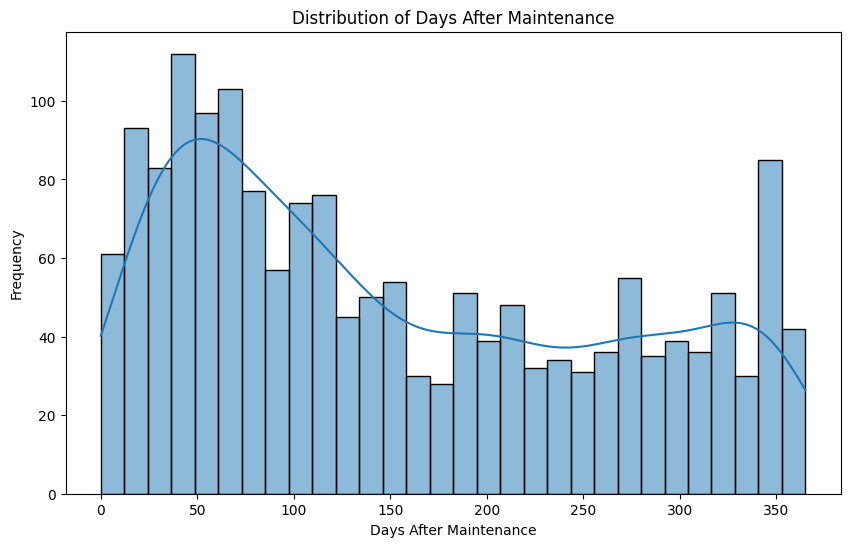

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(merged['DAYS_SINCE_MAINTENANCE'], bins=30, kde=True)
plt.title("Distribution of Days After Maintenance")
plt.xlabel("Days After Maintenance")
plt.ylabel("Frequency")
plt.show()

In [ ]:
merged['YEAR'] = merged['MRI_BEFORE_DATE'].dt.year

In [ ]:
layers_df_delta = layer_df[['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO', 'Added_Thickness']]

In [ ]:
#drop construction number
merged = merged.drop(columns=['CONSTRUCTION_NO'])
merged = merged.merge(layer_df, left_on=['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO_BEFORE'], right_on=['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO'], how='inner')

#remove added thickness
merged = merged.drop(columns=['Added_Thickness'])

#merge with layer_df_delta
merged = merged.drop(columns=['CONSTRUCTION_NO'])
merged = merged.merge(layers_df_delta, left_on=['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO_AFTER'], right_on=['STATE_CODE', 'SHRP_ID', 'CONSTRUCTION_NO'], how='inner')

In [ ]:
merged[merged.Added_Thickness < 0].head()[['STATE_CODE', 'SHRP_ID', 'MAINTENANCE','Added_Thickness']]

,STATE_CODE,SHRP_ID,MAINTENANCE,Added_Thickness
102,4,1017,Mill Off AC and Overlay with AC,-5.1
120,4,1062,"Grinding Surface, Asphalt Concrete Overlay",-20.4
124,4,1065,"Grinding Surface, Asphalt Concrete Overlay",-12.7
128,4,6060,Mill Off AC and Overlay with AC,-5.0
143,4,BA60,Mill Existing Pavement and Overlay with Warm M...,-5.2


In [ ]:
traffic_df_ = traffic_df[['STATE_CODE', 'SHRP_ID', 'YEAR', 'CONSTRUCTION_NO', 'AADTT', 'AGE']]
traffic_df_.head()

,STATE_CODE,SHRP_ID,YEAR,CONSTRUCTION_NO,AADTT,AGE
0,1,0101,1991,1,0,1
1,1,0101,1992,1,0,2
2,1,0101,1993,1,731,3
3,1,0101,1994,1,1484,4
4,1,0101,1995,1,2259,5


In [ ]:
merged = merged.drop(columns=['CONSTRUCTION_NO'])

merged = merged.merge(
    traffic_df_,
    left_on=['STATE_CODE', 'SHRP_ID', 'YEAR', 'CONSTRUCTION_NO_BEFORE'],
    right_on=['STATE_CODE', 'SHRP_ID', 'YEAR', 'CONSTRUCTION_NO'],
    how='inner',
      # Rename duplicate columns
)

In [ ]:
merged[(merged.STATE_CODE == 19) &(merged.SHRP_ID == '1044')].iloc[:, 5:]

,MRI_BEFORE_DATE,MRI_AFTER,MRI_AFTER_DATE,CN_ASSIGN_DATE,MAINTENANCE,DAYS_SINCE_MAINTENANCE,YEAR,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,Added_Thickness,CONSTRUCTION_NO,AADTT,AGE
440,1991-06-22,1.7360,1992-05-13,1992-02-21,"Crack Sealing, Patch Pot Holes - Hand Spread, ...",82,1991,409.0,False,False,True,663.0,0.0,1,4787,21
441,2001-08-09,0.5259,2003-07-26,2002-09-01,"AC Shoulder Restoration, Asphalt Concrete Overlay",328,2001,411.5,False,False,True,665.5,94.0,4,8330,31
442,2003-07-26,0.6746,2007-11-14,2007-01-01,Crack Sealing,317,2003,505.5,False,False,True,759.5,0.0,5,9266,33


In [ ]:
features_columns = ['STATE_CODE', 'SHRP_ID', 'YEAR', 'AGE', 'H_AC', 'Eng_Fab', 'Treated_Base',
                    'Treated_Subbase', 'H_TOT',
                    'MRI_BEFORE', 'MRI_AFTER', 'MAINTENANCE', 'DAYS_SINCE_MAINTENANCE',  \
                        'Added_Thickness', 'AADTT', \
                            ]

In [ ]:
merged[features_columns].head()

,STATE_CODE,SHRP_ID,YEAR,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,MRI_BEFORE,MRI_AFTER,MAINTENANCE,DAYS_SINCE_MAINTENANCE,Added_Thickness,AADTT
0,1,0107,1999,9,116.9,False,True,False,320.1,0.7568,0.9627,Manual Premix Spot Patch (hand spreading and c...,35,0.0,5598
1,1,0502,1991,16,88.9,False,False,False,505.5,1.0360,0.7745,Hot-Mix Recycled Asphalt Concrete Overlay,104,48.3,5434
2,1,0503,1991,16,83.8,False,False,False,500.4,0.9905,0.8260,"AC Shoulder Restoration, Hot-Mix Recycled Asph...",108,124.4,5434
3,1,0504,1991,16,88.9,False,False,False,500.4,1.0307,0.8482,"AC Shoulder Restoration, Asphalt Concrete Overlay",113,116.9,5434
4,1,0505,1991,16,83.9,False,False,False,500.5,1.1372,0.8245,Asphalt Concrete Overlay,104,50.8,5434


In [ ]:
merged[(merged.STATE_CODE == 19) & (merged.SHRP_ID == '6150')][['AGE', 'MAINTENANCE']]

,AGE,MAINTENANCE
445,46,Asphalt Concrete Overlay


In [ ]:
df = merged[features_columns]

In [ ]:
df.to_csv('processed_07_21/Final_Dataset_Drop.csv', index=False)

In [ ]:
df[df['STATE_CODE'] == 19].describe()

,STATE_CODE,YEAR,AGE,H_AC,H_TOT,MRI_BEFORE,MRI_AFTER,DAYS_SINCE_MAINTENANCE,Added_Thickness,AADTT
count,23.0,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,19.0,1998.173913,21.217391,219.126087,799.356522,1.603200,1.367500,122.304348,12.039130,9866.130435
std,0.0,4.667608,13.677973,159.753111,326.413657,0.808489,0.516453,127.137161,34.482851,21295.350368
min,19.0,1990.000000,10.000000,91.400000,292.000000,0.525900,0.476700,36.000000,0.000000,1934.000000
25%,19.0,1995.500000,10.000000,115.600000,589.400000,1.137850,1.062550,36.000000,0.000000,3097.000000
50%,19.0,2001.000000,10.000000,152.400000,919.500000,1.372800,1.330400,36.000000,0.000000,3097.000000
75%,19.0,2001.000000,35.000000,198.150000,1060.450000,1.805150,1.671350,207.500000,0.000000,3292.000000
max,19.0,2003.000000,46.000000,589.400000,1275.100000,4.527900,2.489600,345.000000,139.700000,83573.000000


## IRI_DROP embedding

In [31]:
df = pd.read_csv('processed_07_21/Final_Dataset_Drop.csv')

In [ ]:
from getpass import getpass
from openai import OpenAI

api_key = getpass("Enter your OpenAI API key: ")
client = OpenAI(api_key=api_key)


Enter your OpenAI API key: ··········


In [10]:
# #find unique maiuntenance from df and forma  adictionary
# unique_maintenance = df['MAINTENANCE'].unique()
# print(len(unique_maintenance))
# maintenance_dict = {}
# for i, maintenance in enumerate(unique_maintenance):
#     maintenance_dict[maintenance] = i

102


In [ ]:
# models = {"text-embedding-ada-002": 1536, "text-embedding-3-small": 1536, "text-embedding-3-large": 3072}


# def get_embedding(text, dimension, model="text-embedding-3-large"):
#     text = text.replace("\n", " ")
#     return client.embeddings.create(input = [text], model=model, dimensions=5dimentsion).data[0].embedding
#     # return client.embeddings.create(input = [text], model=model).data[0].embedding


# def create_embed_table(data_dict):
#   for key, value in data_dict.items():
#     data_dict[key] = get_embedding(key, models[model], model)
#   return data_dict

# maintenance_dict = create_embed_table(maintenance_dict)

In [ ]:
import pandas as pd

# Unique maintenance texts
unique_maintenance = df['MAINTENANCE'].unique()
print("Unique Maintenance:", len(unique_maintenance))

# Models and their maximum allowed dimensions
models = {"text-embedding-3-small": 1536, "text-embedding-3-large": 3072}

# Create mapping from text to index (for reproducibility, optional)
maintenance_dict = {text: text for text in unique_maintenance}

# This function fetches the embedding vector
def get_embedding(text, dim, model="text_embedding_3_large"):
    text = text.replace("\n", " ")
    return client.embeddings.create(input = [text], model=model, dimensions=dim).data[0].embedding

# Storage
output_rows = []

# Loop through each model
for model_name, max_dim in models.items():
    for dim in range(128, max_dim + 1, 128):
        for text in unique_maintenance:
            try:
                emb = get_embedding(text, dim, model=model_name)
                row = {"text": text, f"{model_name}_{dim}": emb}
                output_rows.append(row)
            except Exception as e:
                print(f"Skipped {model_name} at dim {dim} due to error: {e}")

# Merge rows into a dataframe
embed_df = pd.DataFrame(output_rows)

# Combine rows with same 'text'
embed_df = embed_df.groupby("text", as_index=False).first()

# Final output
print(embed_df.head())


In [29]:
embed_df.head()

,text,text-embedding-3-small_128,text-embedding-3-small_256,text-embedding-3-small_384,text-embedding-3-small_512,text-embedding-3-small_640,text-embedding-3-small_768,text-embedding-3-small_896,text-embedding-3-small_1024,text-embedding-3-small_1152,...,text-embedding-3-large_1920,text-embedding-3-large_2048,text-embedding-3-large_2176,text-embedding-3-large_2304,text-embedding-3-large_2432,text-embedding-3-large_2560,text-embedding-3-large_2688,text-embedding-3-large_2816,text-embedding-3-large_2944,text-embedding-3-large_3072
0,AC Shoulder Replacement,"[-0.04659799858927727, -0.12649698555469513, 0...","[-0.031830642372369766, -0.08640886843204498, ...","[-0.026324069127440453, -0.07146048545837402, ...","[-0.02265769988298416, -0.06150759756565094, 0...","[-0.02113918960094452, -0.05738538131117821, 0...","[-0.01996253803372383, -0.054191190749406815, ...","[-0.018844328820705414, -0.05115564912557602, ...","[-0.01783447340130806, -0.04841425269842148, 0...","[-0.017086762934923172, -0.04638448357582092, ...",...,"[-0.014538077637553215, 0.0046240342780947685,...","[-0.01428484357893467, 0.0045168730430305, -0....","[-0.014050411060452461, 0.004454785026609898, ...","[-0.013848558068275452, 0.0044047231785953045,...","[-0.013676420785486698, 0.00434997258707881, -...","[-0.013492313213646412, 0.004291414748877287, ...","[-0.013295467011630535, 0.0042288051918148994,...","[-0.013118491508066654, 0.004172515589743853, ...","[-0.012934292666614056, 0.004113928880542517, ...","[-0.012735559605062008, 0.0040507190860807896,..."
1,"AC Shoulder Replacement, Asphalt Concrete Overlay","[-0.08117786049842834, -0.2000730037689209, 0....","[-0.05510646477341652, -0.1358167827129364, 0....","[-0.045124415308237076, -0.1112147644162178, 0...","[-0.037545345723629, -0.09253519773483276, 0.0...","[-0.035338837653398514, -0.08709698170423508, ...","[-0.0330093614757061, -0.08135569840669632, 0....","[-0.031251173466444016, -0.07694118469953537, ...","[-0.029521355405449867, -0.07275907695293427, ...","[-0.02835620567202568, -0.06988741457462311, 0...",...,"[-0.010458135046064854, 0.04088263213634491, -...","[-0.01026981882750988, 0.04021747037768364, -0...","[-0.010098078288137913, 0.03954492136836052, -...","[-0.009981322102248669, 0.0390876941382885, -0...","[-0.009896345436573029, 0.03855181857943535, -...","[-0.009726407937705517, 0.03808942809700966, -...","[-0.009600922465324402, 0.03759801760315895, -...","[-0.009454083628952503, 0.03702298551797867, -...","[-0.00930873490869999, 0.03645378723740578, -0...","[-0.009180511347949505, 0.035951655358076096, ..."
2,"AC Shoulder Replacement, Asphalt Concrete Over...","[-0.10558459907770157, -0.15710726380348206, 0...","[-0.07347781211137772, -0.10933315753936768, 0...","[-0.05985133722424507, -0.0890573039650917, 0....","[-0.05009332299232483, -0.07453761994838715, 0...","[-0.04704679548740387, -0.07000446319580078, 0...","[-0.044031910598278046, -0.06551839411258698, ...","[-0.04139453545212746, -0.06159403920173645, 0...","[-0.03900035098195076, -0.05803155526518822, 0...","[-0.03735723719000816, -0.055586643517017365, ...",...,"[-0.004130374640226364, 0.033886492252349854, ...","[-0.004055676981806755, 0.03327365592122078, -...","[-0.0039829108864068985, 0.03267666697502136, ...","[-0.003931126091629267, 0.032251812517642975, ...","[-0.003882337361574173, 0.03185154125094414, -...","[-0.0038324168417602777, 0.031441982835531235,...","[-0.003784655360504985, 0.03105013631284237, -...","[-0.00372997485101223, 0.03060152381658554, -0...","[-0.003681874368339777, 0.03012368455529213, -...","[-0.003626872319728136, 0.029755650088191032, ..."
3,"AC Shoulder Replacement, Mill Existing Pavemen...","[-0.043194711208343506, -0.18029096722602844, ...","[-0.030897073447704315, -0.1289616972208023, 0...","[-0.02638176642358303, -0.11011520028114319, 0...","[-0.0223037488758564, -0.09309390932321548, 0....","[-0.020933028310537338, -0.08737263828516006, ...","[-0.01986144483089447, -0.08289994299411

In [24]:
# embed_df.columns
#save to parquet
#create new folder
import os
if not os.path.exists('DATA_07_26'):
    os.makedirs('DATA_07_26')
embed_df.to_parquet('DATA_07_26/maintenance_embeddings.parquet')

## Merge the text embedding with origianl df

In [1]:
#connect to google drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.chdir("/content/drive/MyDrive/IowaDOT_IRI")


In [3]:
!ls

 2-28-2025.xml		        FINAL_DATASET.csv
 APP			        Final_Dataset_Drop.csv
 avg_abs_diff_per_section.csv   MAINT_WORK.csv
 Bucket_131088.xlsx	        models_07_21
 Bucket_131089.xlsx	        models_07_26
 Bucket_131276.xlsx	        processed
 Bucket_134704.xlsx	        processed_07_21
 D_ANN_model.pth	        scaled_data.csv
 DATA_07_26		       'Time_series_2 copy.ipynb'
 dataframe_drop.csv	        Time_series_2.ipynb
 dataframe.parquet	        Time_series.ipynb
 FINAL_DATASET_2.csv


## Reload maintenance embed

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('processed_07_21/Final_Dataset_Drop.csv')
embed_df = pd.read_parquet('DATA_07_26/maintenance_embeddings.parquet')

In [5]:
embed_df.head().shape

(5, 37)

In [ ]:
# Function to convert tensors to CPU and flatten them into lists
import torch
def process_embeddings(embedding_array):
    if isinstance(embedding_array, torch.Tensor):
        embedding_array = embedding_array.cpu().numpy()  # Move to CPU and convert to NumPy
    return [float(t) for t in embedding_array.flatten()]  # Convert to list of floats

# idx = 2

for idx in range(1, 37):
  df = pd.read_csv('processed_07_21/Final_Dataset_Drop.csv')
  embed_df = pd.read_parquet('DATA_07_26/maintenance_embeddings.parquet')
  tmp_df = embed_df.iloc[:, [0, idx]]
  df = df.merge(tmp_df, how='left', left_on='MAINTENANCE', right_on='text')
  df = df.drop(columns=['text'])  # optional, to avoid duplicate columns

  # Step 1: Pick the embedding column dynamically (last column or by name)
  embed_col = df.columns[-1]  # or 'text_embedding_3_small_128' if known
  print(embed_col)

  # Step 2: Flatten tensors in that column
  df[embed_col] = df[embed_col].apply(process_embeddings)

  # Step 3: Expand into new columns
  embedding_length = len(df[embed_col].iloc[0])
  print(embedding_length)
  embedding_columns = pd.DataFrame(df[embed_col].tolist(),
                                  columns=[f"embedding_{i}" for i in range(embedding_length)])

  # Step 4: Concatenate with main DataFrame (and drop original embedding col)
  df_total = pd.concat([df.drop(columns=[embed_col]), embedding_columns], axis=1)
  df_total.to_parquet(f'DATA_07_26/dataframe_for_IRI_drop_{embed_col}.parquet')

In [312]:
df_total.head()

,STATE_CODE,SHRP_ID,YEAR,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,MRI_BEFORE,...,embedding_3062,embedding_3063,embedding_3064,embedding_3065,embedding_3066,embedding_3067,embedding_3068,embedding_3069,embedding_3070,embedding_3071
0,1,0107,1999,9,116.9,False,True,False,320.1,0.7568,...,0.004335,-0.005618,-0.024139,-0.005563,0.010066,-0.006694,0.006319,0.011859,0.008311,-0.003234
1,1,0502,1991,16,88.9,False,False,False,505.5,1.0360,...,0.009274,0.003216,-0.013117,-0.024696,0.018116,-0.011996,-0.001920,0.002676,-0.000137,0.004005
2,1,0503,1991,16,83.8,False,False,False,500.4,0.9905,...,0.004121,0.006714,-0.016714,-0.028640,0.015464,-0.024355,-0.011781,0.005216,-0.002827,0.001365
3,1,0504,1991,16,88.9,False,False,False,500.4,1.0307,...,0.016732,0.011571,-0.003712,-0.009541,0.002822,-0.022481,-0.009791,0.005600,-0.006957,0.007661
4,1,0505,1991,16,83.9,False,False,False,500.5,1.1372,...,0.019761,0.007282,-0.000616,-0.001844,0.007570,-0.010653,-0.001771,0.008224,-0.005358,0.002691


In [69]:
# df_total.to_parquet('processed_07_21/dataframe_for_IRI_drop_3KL.parquet')
#save using the embed_col_name
#dump in DATA_07_26 folder
# df_total.to_parquet(f'DATA_07_26/dataframe_for_IRI_drop_{embed_col}.parquet')
# df_total.to_parquet(f'processed_07_21/dataframe_for_IRI_drop_{embed_col}.parquet')

In [313]:
df_total.head()

,STATE_CODE,SHRP_ID,YEAR,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,MRI_BEFORE,...,embedding_3062,embedding_3063,embedding_3064,embedding_3065,embedding_3066,embedding_3067,embedding_3068,embedding_3069,embedding_3070,embedding_3071
0,1,0107,1999,9,116.9,False,True,False,320.1,0.7568,...,0.004335,-0.005618,-0.024139,-0.005563,0.010066,-0.006694,0.006319,0.011859,0.008311,-0.003234
1,1,0502,1991,16,88.9,False,False,False,505.5,1.0360,...,0.009274,0.003216,-0.013117,-0.024696,0.018116,-0.011996,-0.001920,0.002676,-0.000137,0.004005
2,1,0503,1991,16,83.8,False,False,False,500.4,0.9905,...,0.004121,0.006714,-0.016714,-0.028640,0.015464,-0.024355,-0.011781,0.005216,-0.002827,0.001365
3,1,0504,1991,16,88.9,False,False,False,500.4,1.0307,...,0.016732,0.011571,-0.003712,-0.009541,0.002822,-0.022481,-0.009791,0.005600,-0.006957,0.007661
4,1,0505,1991,16,83.9,False,False,False,500.5,1.1372,...,0.019761,0.007282,-0.000616,-0.001844,0.007570,-0.010653,-0.001771,0.008224,-0.005358,0.002691


## IRI_DROP load parquet

In [1]:
#SMALL
# df_total = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop.parquet') # for 512
# # df_total = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop_256.parquet')
# # df_total = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop_1536.parquet')
# # df_total = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop_256L.parquet')
# # df_total = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop_512L.parquet')
# # df_total = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop_3KL.parquet')
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

#read df
idx  = 23
#read embed_df
embed_df = pd.read_parquet('DATA_07_26/maintenance_embeddings.parquet')
tmp_df = embed_df.iloc[:, [0, idx]]
embed_col = tmp_df.columns[1]

print(embed_col)
size = embed_col.split('_')[1]
print(size)

# print(size)
#read the parque tsing the embed_col ref
df_total = pd.read_parquet(f'DATA_07_26/dataframe_for_IRI_drop_{embed_col}.parquet')

df_total = df_total.drop(columns=['MAINTENANCE', 'YEAR'])

text-embedding-3-large_1408
1408


In [2]:
df_total.head().iloc[:, :]

,STATE_CODE,SHRP_ID,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,MRI_BEFORE,MRI_AFTER,...,embedding_1398,embedding_1399,embedding_1400,embedding_1401,embedding_1402,embedding_1403,embedding_1404,embedding_1405,embedding_1406,embedding_1407
0,1,0107,9,116.9,False,True,False,320.1,0.7568,0.9627,...,-0.003858,0.022277,0.018522,-0.030074,0.027424,0.011849,-0.024140,-0.018887,-0.011225,0.012483
1,1,0502,16,88.9,False,False,False,505.5,1.0360,0.7745,...,-0.010778,0.010867,-0.008974,-0.009513,0.005211,0.042043,-0.004935,0.013521,0.001721,0.025315
2,1,0503,16,83.8,False,False,False,500.4,0.9905,0.8260,...,-0.013029,0.006381,0.002852,0.014610,-0.013933,0.042400,-0.018238,0.015000,0.011572,0.023714
3,1,0504,16,88.9,False,False,False,500.4,1.0307,0.8482,...,-0.011344,0.005434,0.003087,0.022729,-0.018802,0.039085,-0.014195,0.022181,0.004320,0.013231
4,1,0505,16,83.9,False,False,False,500.5,1.1372,0.8245,...,-0.025737,0.015198,-0.013559,-0.002282,0.004961,0.039119,-0.014527,0.013954,0.001289,0.020112


### Continued

In [3]:
# df_total.head()
print(df_total.shape)

(1587, 1421)


New Skewness: 0.73


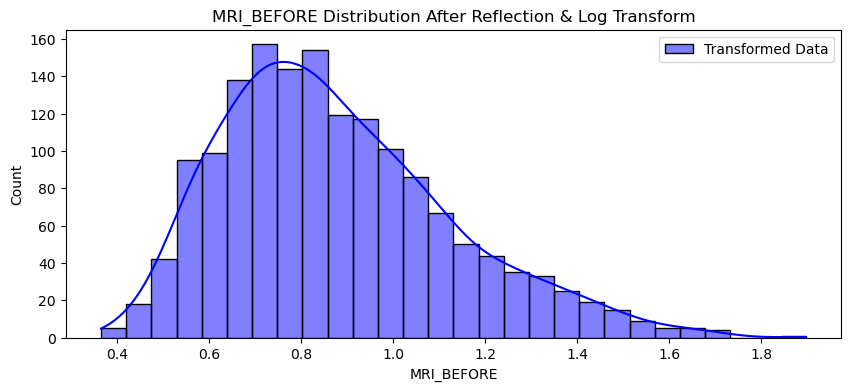

(23, 1421)

In [4]:
df_total.Eng_Fab.value_counts()
df_total.iloc[:,:14].describe()
df_total.iloc[:, 2:13].isna().sum()

sqrt_transform = [ 'H_AC', 'AGE', 'DAYS_SINCE_MAINTENANCE' ]
log_transform = ['H_TOT', 'MRI_BEFORE', 'MRI_AFTER', 'AADTT',  'Added_Thickness']
booleans = ['Eng_Fab', 'Treated_Base', 'Treated_Subbase']

for feature in sqrt_transform:
    df_total[feature] = np.sqrt(df_total[feature])  # Ensure non-negative values

# Apply log transformation (avoid NaN for negative values)
for feature in log_transform:
    df_total[feature] = np.log1p(df_total[feature].clip(0, None))  # Ensure non-negative values
    df_total[feature] = df_total[feature].fillna(0)  # Fill NaNs with 0 (if any)

# Apply integer conversion to booleans (ensure only 0 and 1)
for feature in booleans:
    df_total[feature] = df_total[feature].astype(bool).astype(int)  # Ensures binary 0/1


feature = "MRI_BEFORE"  # Example feature with -1.27 skew

plt.figure(figsize=(10, 4))
sns.histplot(df_total[feature], kde=True, color="blue", label="Transformed Data")
plt.legend()
plt.title(f"{feature} Distribution After Reflection & Log Transform")

# ✅ Print new skewness
print(f"New Skewness: {df_total[feature].skew():.2f}")
plt.show()

df = df_total.copy()
df.columns[2:13]

df[df['STATE_CODE'] == 19].shape

In [5]:
df.columns[13:]

Index(['embedding_0', 'embedding_1', 'embedding_2', 'embedding_3',
       'embedding_4', 'embedding_5', 'embedding_6', 'embedding_7',
       'embedding_8', 'embedding_9',
       ...
       'embedding_1398', 'embedding_1399', 'embedding_1400', 'embedding_1401',
       'embedding_1402', 'embedding_1403', 'embedding_1404', 'embedding_1405',
       'embedding_1406', 'embedding_1407'],
      dtype='object', length=1408)

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.model_selection import train_test_split

# Assign device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

#remove iowa data with state_code 19 from the df
iowa_df = df[df['STATE_CODE'] == 19].copy()
#remove section 1044 and 6049 from iowa
iowa_df = iowa_df[~iowa_df['SHRP_ID'].isin(['1044', '6049'])].copy()
df = df[df['STATE_CODE'] != 19].copy()

# Split the data into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.10, random_state=42)


# Identifying structured features (excluding Boolean columns)
feature_cols_struct = df.columns[2:13]

#subtract MRI, AGE, and bool varible from feature cols struct
feature_cols_struct = [col for col in feature_cols_struct if col not in ["Eng_Fab", "Treated_Base", "Treated_Subbase",\
                                                                          'MRI_AFTER']]
feature_cols_text = df.columns[13:]
print("Text Features:", feature_cols_text)

print("Structured Features:", len(feature_cols_struct))

# ✅ Apply standardization to all and MRI and AGE
ann_standardizer_features = StandardScaler()
train_df[feature_cols_struct] = ann_standardizer_features.fit_transform(train_df[feature_cols_struct])
test_df[feature_cols_struct] = ann_standardizer_features.transform(test_df[feature_cols_struct])
iowa_df[feature_cols_struct] = ann_standardizer_features.transform(iowa_df[feature_cols_struct])

#to MRI
ann_standardizer_target = StandardScaler()
train_df["MRI_AFTER"] = ann_standardizer_target.fit_transform(train_df[["MRI_AFTER"]])
test_df["MRI_AFTER"] = ann_standardizer_target.transform(test_df[["MRI_AFTER"]])
iowa_df["MRI_AFTER"] = ann_standardizer_target.transform(iowa_df[["MRI_AFTER"]])


# ✅ Separating features (X) and target (y)
target_col = "MRI_AFTER"
feature_cols_struct += ["Eng_Fab", "Treated_Base", "Treated_Subbase"]

X_train_struct = train_df[feature_cols_struct]  # Drop MRI
X_train_text = train_df[feature_cols_text]
y_train = train_df[target_col]

X_test_struct = test_df[feature_cols_struct]  # Drop MRI
X_test_text = test_df[feature_cols_text]
y_test = test_df[target_col]

# ✅ Convert to PyTorch tensors and assign to device
X_train_struct_tensor = torch.tensor(X_train_struct.values, dtype=torch.float32).to(device)
X_test_struct_tensor = torch.tensor(X_test_struct.values, dtype=torch.float32).to(device)

X_train_text_tensor = torch.tensor(X_train_text.values, dtype=torch.float32).to(device)
X_test_text_tensor = torch.tensor(X_test_text.values, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)

iowa_x_struct = torch.tensor(iowa_df[feature_cols_struct].values, dtype=torch.float32).to(device)
iowa_x_text = torch.tensor(iowa_df[feature_cols_text].values, dtype=torch.float32).to(device)
iowa_y = torch.tensor(iowa_df[target_col].values, dtype=torch.float32).view(-1, 1).to(device)


#print shape
print("X_train_struct_tensor shape:", X_train_struct_tensor.shape)
print("X_train_text_tensor shape:", X_train_text_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_test_struct_tensor shape:", X_test_struct_tensor.shape)
print("X_test_text_tensor shape:", X_test_text_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)
print("iowa_x_struct shape:", iowa_x_struct.shape)
print("iowa_x_text shape:", iowa_x_text.shape)
print("iowa_y shape:", iowa_y.shape)



Using device: cuda
Text Features: Index(['embedding_0', 'embedding_1', 'embedding_2', 'embedding_3',
       'embedding_4', 'embedding_5', 'embedding_6', 'embedding_7',
       'embedding_8', 'embedding_9',
       ...
       'embedding_1398', 'embedding_1399', 'embedding_1400', 'embedding_1401',
       'embedding_1402', 'embedding_1403', 'embedding_1404', 'embedding_1405',
       'embedding_1406', 'embedding_1407'],
      dtype='object', length=1408)
Structured Features: 7
X_train_struct_tensor shape: torch.Size([1407, 10])
X_train_text_tensor shape: torch.Size([1407, 1408])
y_train_tensor shape: torch.Size([1407, 1])
X_test_struct_tensor shape: torch.Size([157, 10])
X_test_text_tensor shape: torch.Size([157, 1408])
y_test_tensor shape: torch.Size([157, 1])
iowa_x_struct shape: torch.Size([18, 10])
iowa_x_text shape: torch.Size([18, 1408])
iowa_y shape: torch.Size([18, 1])


In [7]:
X_train_text.shape, X_train_struct.shape, y_train.shape, X_test_text.shape, X_test_struct.shape, y_test.shape

((1407, 1408), (1407, 10), (1407,), (157, 1408), (157, 10), (157,))

In [8]:
# train_df.MAINTENANCE.value_counts().head(20)

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import numpy as np
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# Assuming device is already defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Assuming 'size' is defined (e.g., '512' for text embedding dimension)
# Replace with your actual value if not defined
# size = '512'

# ---- 1️⃣ Define Objective Function for Optuna with Cross-Validation ----
def objective(trial):
    # Hyperparameter search space
    reduced_text_size = trial.suggest_int("reduced_text_size", 32, int(eval(size)//2))
    numeric_hidden_size = trial.suggest_int("numeric_hidden_size", 8, 64)
    final_hidden_size = trial.suggest_int("final_hidden_size", 8, 64)
    dropout_text = trial.suggest_float("dropout_text", 0.1, 0.5)
    dropout_numeric = trial.suggest_float("dropout_numeric", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    epochs = trial.suggest_int("epochs", 50, 500)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    criterion_name = trial.suggest_categorical("criterion", ["MSELoss", "SmoothL1Loss"])
    criterion = nn.MSELoss() if criterion_name == "MSELoss" else nn.SmoothL1Loss()
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])
    step_size = trial.suggest_int("step_size", 10, 50)
    gamma = trial.suggest_float("gamma", 0.1, 0.9)

    # Define k-fold cross-validation
    n_splits = 5  # Number of folds
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # Combine training and validation data for k-fold splitting
    X_struct = torch.cat((X_train_struct_tensor, X_test_struct_tensor), dim=0).cpu().numpy()
    X_text = torch.cat((X_train_text_tensor, X_test_text_tensor), dim=0).cpu().numpy()
    y = torch.cat((y_train_tensor, y_test_tensor), dim=0).cpu().numpy()

    val_losses = []

    # Perform k-fold cross-validation
    for train_idx, val_idx in kf.split(X_struct):
        # Split data into training and validation for this fold
        train_struct = torch.tensor(X_struct[train_idx], dtype=torch.float32).to(device)
        train_text = torch.tensor(X_text[train_idx], dtype=torch.float32).to(device)
        train_y = torch.tensor(y[train_idx], dtype=torch.float32).to(device)
        val_struct = torch.tensor(X_struct[val_idx], dtype=torch.float32).to(device)
        val_text = torch.tensor(X_text[val_idx], dtype=torch.float32).to(device)
        val_y = torch.tensor(y[val_idx], dtype=torch.float32).to(device)

        # ---- 2️⃣ Define Model with Sampled Hyperparameters ----
        class DualBranchNN(nn.Module):
            def __init__(self, input_size_numeric, input_size_text):
                super(DualBranchNN, self).__init__()

                # Text processing branch
                self.text_branch = nn.Sequential(
                    nn.Linear(input_size_text, reduced_text_size),
                    nn.ReLU(),
                    nn.Dropout(dropout_text)
                )

                # Structured data branch
                self.numeric_branch = nn.Sequential(
                    nn.Linear(input_size_numeric, numeric_hidden_size),
                    nn.ReLU(),
                    nn.Dropout(dropout_numeric)
                )

                # Merging both branches
                self.final_layer = nn.Sequential(
                    nn.Linear(reduced_text_size + numeric_hidden_size, final_hidden_size),
                    nn.ReLU(),
                    nn.Linear(final_hidden_size, 1)
                )

            def forward(self, text_embedding, numeric_features):
                text_out = self.text_branch(text_embedding)
                num_out = self.numeric_branch(numeric_features)
                combined = torch.cat((text_out, num_out), dim=1)
                output = self.final_layer(combined)
                return output

        # Instantiate model
        model = DualBranchNN(input_size_numeric=train_struct.shape[1],
                             input_size_text=train_text.shape[1]).to(device)

        # ---- 3️⃣ Optimizer and Scheduler Setup ----
        if optimizer_name == "Adam":
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        elif optimizer_name == "SGD":
            optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay, momentum=0.9)
        elif optimizer_name == "RMSprop":
            optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

        # ---- 4️⃣ Training Function ----
        def train_model(model, train_struct, train_text, train_y, val_struct, val_text, val_y, epochs, batch_size):
            train_dataset = torch.utils.data.TensorDataset(train_struct, train_text, train_y)
            val_dataset = torch.utils.data.TensorDataset(val_struct, val_text, val_y)

            train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

            for epoch in range(epochs):
                model.train()
                epoch_loss = 0
                for batch_struct, batch_text, batch_y in train_loader:
                    optimizer.zero_grad()
                    outputs = model(batch_text, batch_struct)
                    loss = criterion(outputs, batch_y)
                    loss.backward()
                    optimizer.step()
                    epoch_loss += loss.item()

                scheduler.step()  # Adjust learning rate

            # Validation loss calculation
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_struct, batch_text, batch_y in val_loader:
                    val_pred = model(batch_text, batch_struct)
                    loss = criterion(val_pred, batch_y).item()
                    val_loss += loss
            return val_loss / len(val_loader)  # Average validation loss

        # ---- 5️⃣ Train Model and Compute Validation Loss ----
        val_loss = train_model(model, train_struct, train_text, train_y,
                               val_struct, val_text, val_y, epochs, batch_size)
        val_losses.append(val_loss)

    # Return average validation loss across folds
    return np.mean(val_losses)

# ---- 6️⃣ Run Bayesian Optimization ----
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)  # Adjust number of trials as needed

# Print best hyperparameters and validation loss
print("Best hyperparameters:", study.best_params)
print("Best validation loss:", study.best_value)



[I 2025-07-27 18:14:58,876] A new study created in memory with name: no-name-dce7e38f-37c4-40f9-93b9-68013f0eb65b


Using device: cuda


[I 2025-07-27 18:15:13,493] Trial 0 finished with value: 0.956072493394216 and parameters: {'reduced_text_size': 210, 'numeric_hidden_size': 61, 'final_hidden_size': 16, 'dropout_text': 0.36184417793365276, 'dropout_numeric': 0.3040370085939845, 'lr': 5.270459987719568e-05, 'weight_decay': 5.368313923046729e-05, 'epochs': 162, 'batch_size': 128, 'criterion': 'MSELoss', 'optimizer': 'SGD', 'step_size': 10, 'gamma': 0.44135996652625387}. Best is trial 0 with value: 0.956072493394216.
[I 2025-07-27 18:15:53,922] Trial 1 finished with value: 0.10890328337748845 and parameters: {'reduced_text_size': 160, 'numeric_hidden_size': 21, 'final_hidden_size': 48, 'dropout_text': 0.29172205984660937, 'dropout_numeric': 0.15424809967809017, 'lr': 0.0020966703507547314, 'weight_decay': 0.0005466881992560436, 'epochs': 405, 'batch_size': 128, 'criterion': 'SmoothL1Loss', 'optimizer': 'RMSprop', 'step_size': 49, 'gamma': 0.16063400435492642}. Best is trial 1 with value: 0.10890328337748845.
[I 2025-07-2

Best hyperparameters: {'reduced_text_size': 118, 'numeric_hidden_size': 35, 'final_hidden_size': 40, 'dropout_text': 0.422404650216562, 'dropout_numeric': 0.23899183062067733, 'lr': 0.0005223119461773743, 'weight_decay': 1.6777717912137861e-06, 'epochs': 329, 'batch_size': 32, 'criterion': 'SmoothL1Loss', 'optimizer': 'RMSprop', 'step_size': 18, 'gamma': 0.6744369842738644}
Best validation loss: 0.1047356727719307


In [10]:
print("Best Hyperparameters:", study.best_params)

Best Hyperparameters: {'reduced_text_size': 118, 'numeric_hidden_size': 35, 'final_hidden_size': 40, 'dropout_text': 0.422404650216562, 'dropout_numeric': 0.23899183062067733, 'lr': 0.0005223119461773743, 'weight_decay': 1.6777717912137861e-06, 'epochs': 329, 'batch_size': 32, 'criterion': 'SmoothL1Loss', 'optimizer': 'RMSprop', 'step_size': 18, 'gamma': 0.6744369842738644}


In [11]:
best_params = study.best_params


Using device: cuda
Combined training data shapes: X_struct=torch.Size([1564, 10]), X_text=torch.Size([1564, 1408]), y=torch.Size([1564, 1])
Iowa test data shapes: X_struct=torch.Size([18, 10]), X_text=torch.Size([18, 1408]), y=torch.Size([18, 1])
Training model for 329 epochs...


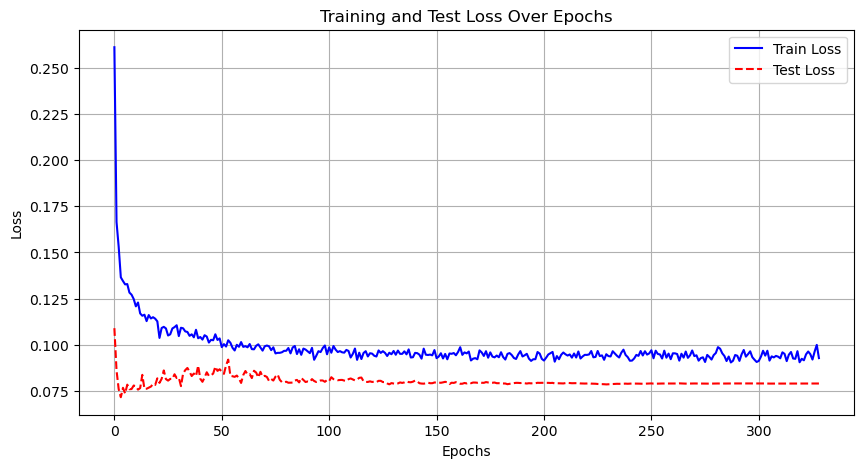

Iowa Test Loss: 0.0791
Iowa Test MAE: 0.2722
Iowa Test RMSE: 0.4020
Final model saved successfully!


In [12]:
# ```python
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Assuming device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Assuming best_params, X_train_struct_tensor, X_train_text_tensor, y_train_tensor,
# X_test_struct_tensor, X_test_text_tensor, y_test_tensor, iowa_x_struct, iowa_x_text, iowa_y
# are already defined with appropriate shapes and types

# ---- 1️⃣ Define DualBranchNN Model ----
class DualBranchNN(nn.Module):
    def __init__(self, input_size_numeric, input_size_text, best_params):
        super(DualBranchNN, self).__init__()

        # Optimized text processing branch
        self.text_branch = nn.Sequential(
            nn.Linear(input_size_text, best_params["reduced_text_size"]),
            nn.ReLU(),
            nn.Dropout(best_params["dropout_text"])
        )

        # Optimized structured data branch
        self.numeric_branch = nn.Sequential(
            nn.Linear(input_size_numeric, best_params["numeric_hidden_size"]),
            nn.ReLU(),
            nn.Dropout(best_params["dropout_numeric"])
        )

        # Optimized merged final layer
        self.final_layer = nn.Sequential(
            nn.Linear(best_params["reduced_text_size"] + best_params["numeric_hidden_size"],
                      best_params["final_hidden_size"]),
            nn.ReLU(),
            nn.Linear(best_params["final_hidden_size"], 1)
        )

    def forward(self, text_embedding, numeric_features):
        text_out = self.text_branch(text_embedding)
        num_out = self.numeric_branch(numeric_features)
        combined = torch.cat((text_out, num_out), dim=1)
        output = self.final_layer(combined)
        return output

# ---- 2️⃣ Concatenate Training and Validation Data ----
X_struct_final = torch.cat((X_train_struct_tensor, X_test_struct_tensor), dim=0).to(device)
X_text_final = torch.cat((X_train_text_tensor, X_test_text_tensor), dim=0).to(device)
y_final = torch.cat((y_train_tensor, y_test_tensor), dim=0).to(device)

# Verify shapes
print(f"Combined training data shapes: X_struct={X_struct_final.shape}, X_text={X_text_final.shape}, y={y_final.shape}")
print(f"Iowa test data shapes: X_struct={iowa_x_struct.shape}, X_text={iowa_x_text.shape}, y={iowa_y.shape}")

# ---- 3️⃣ Instantiate Model with Best Hyperparameters ----
model = DualBranchNN(
    input_size_numeric=X_struct_final.shape[1],
    input_size_text=X_text_final.shape[1],
    best_params=best_params
).to(device)

# ---- 4️⃣ Set Up Loss Function, Optimizer, and Scheduler ----
criterion = nn.MSELoss() if best_params["criterion"] == "MSELoss" else nn.SmoothL1Loss()

if best_params["optimizer"] == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])
elif best_params["optimizer"] == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"], momentum=0.9)
elif best_params["optimizer"] == "RMSprop":
    optimizer = optim.RMSprop(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=best_params["step_size"], gamma=best_params["gamma"])

# ---- 5️⃣ Create DataLoaders ----
batch_size = best_params["batch_size"]
train_dataset = TensorDataset(X_struct_final, X_text_final, y_final)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(iowa_x_struct, iowa_x_text, iowa_y)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ---- 6️⃣ Training Function with Loss Tracking ----
def train_model(model, train_loader, test_loader, epochs):
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0
        for batch_struct, batch_text, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_text, batch_struct)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        # Average training loss for the epoch
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Evaluation phase
        model.eval()
        epoch_test_loss = 0
        with torch.no_grad():
            for batch_struct, batch_text, batch_y in test_loader:
                outputs = model(batch_text, batch_struct)
                loss = criterion(outputs, batch_y).item()
                epoch_test_loss += loss

        # Average test loss for the epoch
        avg_test_loss = epoch_test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        scheduler.step()
        # print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

    return train_losses, test_losses

# ---- 7️⃣ Evaluation Function ----
def evaluate_model(model, test_loader):
    model.eval()
    test_loss = 0
    predictions = []
    actuals = []
    with torch.no_grad():
        for batch_struct, batch_text, batch_y in test_loader:
            outputs = model(batch_text, batch_struct)
            loss = criterion(outputs, batch_y).item()
            test_loss += loss
            predictions.append(outputs.cpu().numpy())
            actuals.append(batch_y.cpu().numpy())
    predictions = np.concatenate(predictions)
    actuals = np.concatenate(actuals)
    avg_test_loss = test_loss / len(test_loader)
    return avg_test_loss, predictions, actuals

# ---- 8️⃣ Train the Model and Track Losses ----
epochs = best_params["epochs"]
print(f"Training model for {epochs} epochs...")
train_losses, test_losses = train_model(model, train_loader, test_loader, epochs)

# ---- 9️⃣ Plot Training and Test Loss ----
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", color="blue", linestyle="-")
plt.plot(test_losses, label="Test Loss", color="red", linestyle="--")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Test Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

# ---- 10️⃣ Evaluate on Iowa Test Set ----
test_loss, predictions, actuals = evaluate_model(model, test_loader)
print(f"Iowa Test Loss: {test_loss:.4f}")

# ---- 11️⃣ Compute Additional Metrics ----
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
print(f"Iowa Test MAE: {mae:.4f}")
print(f"Iowa Test RMSE: {rmse:.4f}")

# ---- 12️⃣ Save the Model ----
torch.save(model.state_dict(), "models_07_26/DualBranchNN_final_model.pth")
print("Final model saved successfully!")


y_train_tensor_final shape: torch.Size([1564, 1])
R² Score: 0.8253
Mean Absolute Error: 0.1728


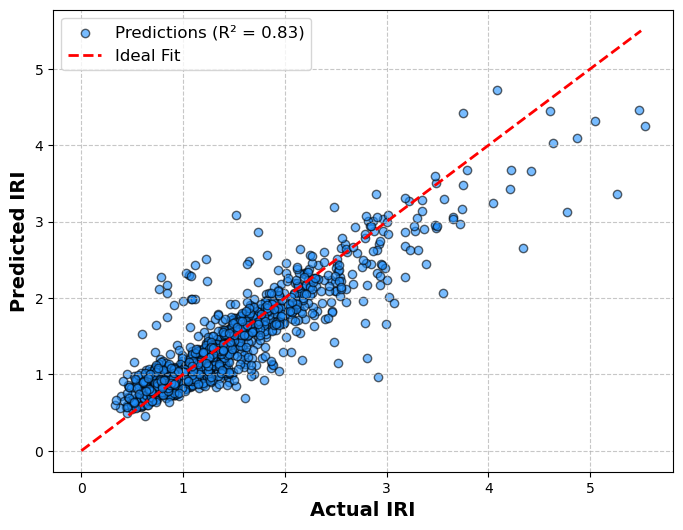

In [13]:
model.eval()
with torch.no_grad():
#concat train and test data
    X_train_text_tensor_final = torch.cat((X_train_text_tensor, X_test_text_tensor), dim=0)
    X_train_struct_tensor_final = torch.cat((X_train_struct_tensor, X_test_struct_tensor), dim=0)
    test_preds_scaled = model(X_train_text_tensor_final, X_train_struct_tensor_final)

#trasnform invers using standard
test_preds_original = ann_standardizer_target.inverse_transform(test_preds_scaled.cpu().numpy())
test_preds_original = np.expm1(test_preds_original)

# y_test_original = ann_standardizer_target.inverse_transform(y_test_tensor.cpu().numpy())\
#concat y_train and y_test
y_train_tensor_final = torch.cat((y_train_tensor, y_test_tensor), dim=0)
print("y_train_tensor_final shape:", y_train_tensor_final.shape)
#inverse transform
y_test_original = ann_standardizer_target.inverse_transform(y_train_tensor_final.cpu().numpy())
# y_test_original = ann_standardizer_target.inverse_transform(y_train_tensor.cpu().numpy())


# y_test_original = np.square(y_test_original)
y_test_original = np.expm1(y_test_original)

# ✅ Scatter Plot of Predictions
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# ✅ Compute R² Score
r2 = r2_score(y_test_original, test_preds_original)
print(f"R² Score: {r2:.4f}")


#print rmse
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse = sqrt(mean_squared_error(y_test_original, test_preds_original))
# print(f"RMSE: {rmse:.4f}")
mean_absolute_error = np.mean(np.abs(y_test_original - test_preds_original))
print(f"Mean Absolute Error: {mean_absolute_error:.4f}")

# ✅ Create figure
plt.figure(figsize=(8, 6))

# ✅ Scatter plot with improved styling
plt.scatter(
    y_test_original, test_preds_original, alpha=0.6, edgecolors="black", color="dodgerblue", label="Predictions"
)

# ✅ Add 1:1 Perfect Match Line
plt.plot(
    [0, 5.5],  # Fixed range for X-axis
    [0, 5.5],  # Fixed range for Y-axis
    'r--', linewidth=2, label="Ideal Fit (1:1 Line)"
)

# ✅ Add R² score in the legend
plt.legend([f"Predictions (R² = {r2:.2f})", "Ideal Fit"], loc="upper left", fontsize=12)

# ✅ Labels and Title
plt.xlabel("Actual IRI", fontsize=14, fontweight="bold")
plt.ylabel("Predicted IRI", fontsize=14, fontweight="bold")
# plt.title("Actual vs Predicted IRI", fontsize=16, fontweight="bold")

# ✅ Add grid for better readability
plt.grid(True, linestyle="--", alpha=0.7)

# ✅ Show the plot
plt.show()

y_test_original shape: (18, 1)
R² Score: 0.7474
Mean Absolute Error: 0.1567


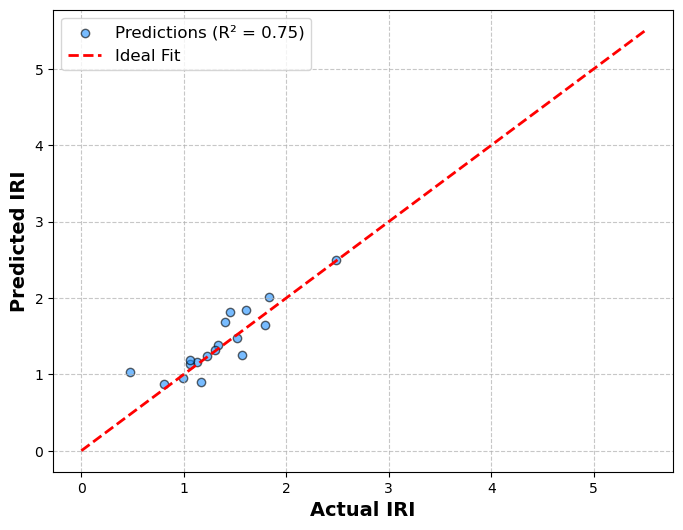

In [ ]:
model.eval()
with torch.no_grad():
    #use iow data
    test_preds_scaled = model(iowa_x_text, iowa_x_struct)
0
    # test_preds_scaled = model(X_test_text_tensor, X_test_struct_tensor)
    # test_preds_scaled = model(X_train_text_tensor, X_train_struct_tensor)

#trasnform invers using standard
test_preds_original = ann_standardizer_target.inverse_transform(test_preds_scaled.cpu().numpy())
test_preds_original = np.expm1(test_preds_original)

# y_test_original = ann_standardizer_target.inverse_transform(y_test_tensor.cpu().numpy())
# use iowa data
y_test_original = ann_standardizer_target.inverse_transform(iowa_y.cpu().numpy())
print("y_test_original shape:", y_test_original.shape)
# y_test_original = ann_standardizer_target.inverse_transform(y_train_tensor.cpu().numpy())


# y_test_original = np.square(y_test_original)
y_test_original = np.expm1(y_test_original)

# ✅ Scatter Plot of Predictions
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# ✅ Compute R² Score
r2 = r2_score(y_test_original, test_preds_original)
print(f"R² Score: {r2:.4f}")


#print rmse
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse = sqrt(mean_squared_error(y_test_original, test_preds_original))
mean_absolute_error = np.mean(np.abs(y_test_original - test_preds_original))
print(f"Mean Absolute Error: {mean_absolute_error:.4f}")
# print(f"RMSE: {rmse:.4f}")

# ✅ Create figure
plt.figure(figsize=(8, 6))

# ✅ Scatter plot with improved styling
plt.scatter(
    y_test_original, test_preds_original, alpha=0.6, edgecolors="black", color="dodgerblue", label="Predictions"
)

# ✅ Add 1:1 Perfect Match Line
plt.plot(
    [0, 5.5],  # Fixed range for X-axis
    [0, 5.5],  # Fixed range for Y-axis
    'r--', linewidth=2, label="Ideal Fit (1:1 Line)"
)

# ✅ Add R² score in the legend
plt.legend([f"Predictions (R² = {r2:.2f})", "Ideal Fit"], loc="upper left", fontsize=12)

# ✅ Labels and Title
plt.xlabel("Actual IRI", fontsize=14, fontweight="bold")
plt.ylabel("Predicted IRI", fontsize=14, fontweight="bold")
# plt.title("Actual vs Predicted IRI", fontsize=16, fontweight="bold")

# ✅ Add grid for better readability
plt.grid(True, linestyle="--", alpha=0.7)

# ✅ Show the plot
plt.show()


In [15]:
# 
# change to df y_test_original, test_preds_original
df_results = pd.DataFrame({
    'Actual IRI': y_test_original.flatten(),
    'Predicted IRI': test_preds_original.flatten()
})
df_results['Difference'] = df_results['Actual IRI'] - df_results['Predicted IRI']
df_results['Absolute Difference'] = df_results['Difference'].abs()
df_results['Absolute Difference'].mean()

0.15665232

In [16]:
df_results

,Actual IRI,Predicted IRI,Difference,Absolute Difference
0,1.8356,2.011897,-0.176297,0.176297
1,2.4896,2.494978,-0.005378,0.005378
2,1.5163,1.472655,0.043645,0.043645
3,1.3304,1.383673,-0.053273,0.053273
4,1.4461,1.822307,-0.376207,0.376207
5,1.3091,1.318335,-0.009235,0.009235
6,1.1273,1.166316,-0.039016,0.039016
7,1.6067,1.836615,-0.229915,0.229915
8,1.1693,0.900244,0.269055,0.269055
9,1.4055,1.686558,-0.281058,0.281058


In [17]:
import torch

# Save model state_dict (recommended method)
#create new folder fro model
if not os.path.exists("models_07_26"):
    os.makedirs("models_07_26")
    # add new dfolder inside tjhe models_07_26

if not os.path.exists(f"models_07_26/{embed_col}"):
    os.makedirs(f"models_07_26/{embed_col}")
torch.save(model.state_dict(), f"models_07_26/{embed_col}/DualBranchNN_model.pth")


print("✅ DualBranchNN model saved successfully!")

✅ DualBranchNN model saved successfully!


In [18]:
import joblib

# Save the standardizer
# joblib.dump(ann_standardizer_features, "models_07_21/ANN_standardizer_features_3KL.joblib")
# joblib.dump(ann_standardizer_target, "models_07_21/ANN_standardizer_target_3KL.joblib")

#update using the new model and ethe embed_col
joblib.dump(ann_standardizer_features, f"models_07_26/{embed_col}/ANN_standardizer_features.joblib")
joblib.dump(ann_standardizer_target, f"models_07_26/{embed_col}/ANN_standardizer_target.joblib")

['models_07_26/text-embedding-3-large_1408/ANN_standardizer_target.joblib']

In [19]:
ANN_features = {}
ANN_features['best_params'] = best_params
ANN_features['ann_features'] = feature_cols_struct[:-3]

In [20]:
ANN_features

{'best_params': {'reduced_text_size': 118,
  'numeric_hidden_size': 35,
  'final_hidden_size': 40,
  'dropout_text': 0.422404650216562,
  'dropout_numeric': 0.23899183062067733,
  'lr': 0.0005223119461773743,
  'weight_decay': 1.6777717912137861e-06,
  'epochs': 329,
  'batch_size': 32,
  'criterion': 'SmoothL1Loss',
  'optimizer': 'RMSprop',
  'step_size': 18,
  'gamma': 0.6744369842738644},
 'ann_features': ['AGE',
  'H_AC',
  'H_TOT',
  'MRI_BEFORE',
  'DAYS_SINCE_MAINTENANCE',
  'Added_Thickness',
  'AADTT']}

In [21]:
import json

# Save to JSON file
with open(f"models_07_26/{embed_col}/ANN_features.json", "w") as f:
    json.dump(ANN_features, f, indent=4)

print("ANN features saved successfully!")

ANN features saved successfully!


### End of Processing

## Final dataset IRI progression

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
# !pip install seaborn
import seaborn as sns
# os.chdir('drive/My Drive/TRB_CODE_DATA/Conference data/')

weather_df = pd.read_csv('processed_07_21/MERRA_PROCESSED')
iri_df = pd.read_csv('processed_07_21/ANALYSIS_IRI_PROCESSED')
layer_df = pd.read_csv('processed_07_21/TST_L05B_PROCESSED')
traffic_df = pd.read_csv('processed_07_21/TRF_TREND_PROCESSED')
reference_df = pd.read_csv('processed_07_21/WEATHER_REFERNCE')
maintenance_df = pd.read_csv('processed_07_21/MAINTENANCE_PROCESSED')

In [ ]:
iri_df

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,Initial_IRI
0,1,0101,1,1995,1995-10-30,0.657300,0.6573
1,1,0101,1,1996,1996-06-02,0.681225,0.6573
2,1,0101,1,1997,1997-08-24,0.694600,0.6573
3,1,0101,1,1998,1998-06-23,0.738225,0.6573
4,1,0101,1,1999,1999-09-28,0.713700,0.6573
...,...,...,...,...,...,...,...
13684,90,B351,2,1994,1994-07-19,1.644600,1.4531
13685,90,B351,2,1995,1995-05-25,1.925900,1.4531
13686,90,B351,3,1997,1997-04-29,2.495300,2.4953
13687,90,B351,3,1998,1998-08-28,2.533100,2.4953


In [ ]:
reference_df.head()

,MERRA_ID,STATE_CODE,SHRP_ID
0,118838,72,4121
1,128580,48,0122
2,128580,48,0114
3,128608,12,0104
4,128608,12,0105


In [ ]:
merged_df = iri_df.merge(reference_df, on=['STATE_CODE', 'SHRP_ID'], how='inner')
print(len(merged_df))

13689


In [ ]:
weather_df.rename(columns={'YEAR': 'YEAR_VISITED'}, inplace=True)

merged_df = merged_df.merge(weather_df, on=['MERRA_ID', 'YEAR_VISITED'], how='inner')

In [ ]:
merged_df.head()

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,Initial_IRI,MERRA_ID,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG
0,1,0101,1,1995,1995-10-30,0.657300,0.6573,135513,1258.24,17.900000,7.0,54.0,75
1,1,0101,1,1996,1996-06-02,0.681225,0.6573,135513,1201.48,17.200001,27.0,54.0,76
2,1,0101,1,1997,1997-08-24,0.694600,0.6573,135513,1475.31,17.400000,5.0,31.0,78
3,1,0101,1,1998,1998-06-23,0.738225,0.6573,135513,1396.67,18.799999,0.0,23.0,76
4,1,0101,1,1999,1999-09-28,0.713700,0.6573,135513,1145.22,18.500000,6.0,35.0,71


In [ ]:
merged_df = merged_df.dropna()
traffic_df

,STATE_CODE,SHRP_ID,YEAR,CONSTRUCTION_NO,AADTT_ALL_TRUCKS_TREND,AADTT,AGE
0,1,0101,1991,1,0,0,1
1,1,0101,1992,1,0,0,2
2,1,0101,1993,1,731,731,3
3,1,0101,1994,1,753,1484,4
4,1,0101,1995,1,775,2259,5
...,...,...,...,...,...,...,...
54300,90,B351,1998,2,185,3741,30
54301,90,B351,1998,3,185,3741,30
54302,90,B351,1999,1,180,3921,31
54303,90,B351,1999,2,180,3921,31


In [ ]:
traffic_df.rename(columns={'YEAR': 'YEAR_VISITED'}, inplace=True)
merged_df_cleaned = merged_df.merge(traffic_df, on=['SHRP_ID', 'STATE_CODE', 'YEAR_VISITED', 'CONSTRUCTION_NO'], how='inner')

In [ ]:
len(merged_df_cleaned)

12915

In [ ]:
layer_df.head()

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,Added_Thickness
0,1,0101,1,188.0,False,False,False,388.7,0.0
1,1,0102,1,106.7,False,False,False,411.5,0.0
2,1,0102,2,106.7,False,False,False,411.5,0.0
3,1,0103,1,106.7,False,True,False,294.7,0.0
4,1,0104,1,160.1,False,True,False,470.0,0.0


In [ ]:
merged_df_cleaned = merged_df_cleaned.merge(layer_df, on=['SHRP_ID', 'CONSTRUCTION_NO', 'STATE_CODE'], how='inner')

In [ ]:
merged_df_cleaned = merged_df_cleaned.drop_duplicates().reset_index(drop=True)

In [ ]:
merged_df_cleaned = merged_df_cleaned.dropna()

In [ ]:
dataframe = merged_df_cleaned.copy()
dataframe=dataframe.reset_index(drop=True)

In [ ]:
dataframe[(dataframe['SHRP_ID'] == '1803')  & (dataframe['STATE_CODE']==9)]

In [ ]:
dataframe.drop(columns=['MERRA_ID', 'AADTT_ALL_TRUCKS_TREND'], inplace=True)

In [ ]:
dataframe = dataframe.dropna()

In [ ]:
dataframe.isna().sum()
len(dataframe)

12915

In [ ]:
dataframe[(dataframe['SHRP_ID']=='1803') & (dataframe['STATE_CODE']==9)]

In [ ]:
# dataframe.to_csv('processed_07_21/FINAL_DATASET_for_IRI_progression.csv', index=False)

## Iowa data for progession

In [ ]:
df = pd.read_csv('processed_07_21/FINAL_DATASET_for_IRI_progression2.csv')
table_name = 'EXPERIMENT_SECTION'

excel_file = 'Bucket_131276.xlsx'
maintenance_df = pd.read_excel(excel_file, sheet_name=table_name)
# df.drop(columns=['Initial_IRI', 'Added_Thickness'], inplace=True)

In [ ]:
df.head()

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG,AADTT,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,Days_since_last_MRI
0,1,0101,1,1995,1995-10-30,0.657300,1258.24,17.900000,7.0,54.0,75,2259,5,188.0,False,False,False,388.7,0.0
1,1,0101,1,1996,1996-06-02,0.681225,1201.48,17.200001,27.0,54.0,76,3057,6,188.0,False,False,False,388.7,216.0
2,1,0101,1,1997,1997-08-24,0.694600,1475.31,17.400000,5.0,31.0,78,3879,7,188.0,False,False,False,388.7,448.0
3,1,0101,1,1998,1998-06-23,0.738225,1396.67,18.799999,0.0,23.0,76,4726,8,188.0,False,False,False,388.7,303.0
4,1,0101,1,1999,1999-09-28,0.713700,1145.22,18.500000,6.0,35.0,71,5598,9,188.0,False,False,False,388.7,462.0


In [ ]:
# develop acolumn that says the number of days since last MRI inspection
#sort and find the differnces
# Convert VISIT_DATE to datetime
# df['VISIT_DATE'] = pd.to_datetime(df['VISIT_DATE'], errors='coerce')
# df = df.sort_values(by=['STATE_CODE', 'SHRP_ID', 'YEAR_VISITED'])
# df['Days_since_last_MRI'] = df.groupby(['STATE_CODE', 'SHRP_ID'])['VISIT_DATE'].diff().dt.days
# #replace nan with 0
# df['Days_since_last_MRI'] = df['Days_since_last_MRI'].fillna(0)

In [ ]:
df.describe()

,STATE_CODE,CONSTRUCTION_NO,YEAR_VISITED,MRI,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG,AADTT,AGE,H_AC,H_TOT,Days_since_last_MRI
count,12915.000000,12915.000000,12915.000000,12915.000000,12915.000000,12915.000000,12915.000000,12915.000000,12915.000000,12915.000000,12915.000000,12915.000000,12915.000000,12915.000000
mean,33.285327,2.123732,1998.609059,1.298215,919.849208,12.645683,350.764847,73.673790,67.563376,11272.403175,19.784282,177.035610,602.412830,474.182036
std,23.209551,1.242299,6.773208,0.611568,444.653699,6.138046,478.551356,42.846963,13.373070,17645.378419,10.253489,82.900377,329.191633,359.555749
min,1.000000,1.000000,1989.000000,0.319400,11.480000,-5.600000,0.000000,0.000000,25.000000,7.000000,1.000000,22.800000,159.900000,0.000000
25%,13.000000,1.000000,1993.000000,0.876100,571.900000,7.400000,4.000000,37.000000,61.000000,2823.000000,12.000000,114.300000,401.300000,296.000000
50%,30.000000,2.000000,1998.000000,1.143300,951.940000,12.600000,123.000000,79.000000,73.000000,6044.000000,19.000000,170.200000,543.500000,389.000000
75%,48.000000,3.000000,2003.000000,1.537200,1245.210000,17.550000,552.000000,103.000000,77.000000,12367.000000,27.000000,223.500000,716.300000,630.000000
max,90.000000,15.000000,2021.000000,5.742900,3708.850000,26.600000,3647.000000,189.000000,89.000000,238783.000000,60.000000,614.600000,5831.700000,6169.000000


In [ ]:
# df.to_csv('processed_07_21/FINAL_DATASET_for_IRI_progression2.csv', index=False)
df.Treated_Subbase.value_counts()

,count
Treated_Subbase,
False,10794
True,2121


In [ ]:
df.iloc[:, 5:].skew()

,0
MRI,1.770643
PRECIPITATION,0.156093
TEMP_MEAN_AVG,0.087922
FREEZE_INDEX,1.627992
FREEZE_THAW,-0.126319
REL_HUM_AVG_AVG,-1.150738
AADTT,4.643819
AGE,0.507847
H_AC,0.906915
Eng_Fab,4.642649


In [ ]:
srt_feaures = ['FREEZE_INDEX', 'H_AC', 'MRI', 'AGE']
log_features = ['AADTT', 'H_TOT', 'Days_since_last_MRI']
boolean_features = ['Eng_Fab', 'Treated_Base', 'Treated_Subbase']

#apply the transformations
df[srt_feaures] = np.sqrt(df[srt_feaures])
df[log_features] = np.log1p(df[log_features])
df[boolean_features] = df[boolean_features].astype(int)

In [ ]:
iowa_df = df[df['STATE_CODE']==19].reset_index(drop=True)
df = df[df['STATE_CODE']!=19].reset_index(drop=True)

# train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# randomly split based on state code not just random sample frac
#show all the state code and pick test adn train from it
state_codes = df['STATE_CODE'].unique()

print(state_codes, len(state_codes))
train_state_codes = np.random.choice(state_codes, size=int(len(state_codes)*0.9), replace=False)
test_state_codes = np.setdiff1d(state_codes, train_state_codes)

train_df = df[df['STATE_CODE'].isin(train_state_codes)].reset_index(drop=True)
test_df = df[df['STATE_CODE'].isin(test_state_codes)].reset_index(drop=True)


[ 1  2  4  5  6  8  9 10 11 12 13 15 16 17 18 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 45 46 47 48 49 50 51 53 54 55
 56 72 81 82 83 84 85 86 87 88 89 90] 60


In [ ]:
max_train = train_df['REL_HUM_AVG_AVG'].max()
train_df['REL_HUM_AVG_AVG'] = np.log1p(max_train - train_df['REL_HUM_AVG_AVG'])
test_df['REL_HUM_AVG_AVG'] = np.log1p(max_train - test_df['REL_HUM_AVG_AVG'])
iowa_df['REL_HUM_AVG_AVG'] = np.log1p(max_train - iowa_df['REL_HUM_AVG_AVG'])

In [ ]:
train_df.head()

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG,AADTT,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,Days_since_last_MRI
0,1,0101,1,1995,1995-10-30,0.810740,1258.24,17.900000,2.645751,54.0,2.708050,7.723120,2.236068,13.711309,0,0,0,5.965377,0.000000
1,1,0101,1,1996,1996-06-02,0.825364,1201.48,17.200001,5.196152,54.0,2.639057,8.025516,2.449490,13.711309,0,0,0,5.965377,5.379897
2,1,0101,1,1997,1997-08-24,0.833427,1475.31,17.400000,2.236068,31.0,2.484907,8.263590,2.645751,13.711309,0,0,0,5.965377,6.107023
3,1,0101,1,1998,1998-06-23,0.859200,1396.67,18.799999,0.000000,23.0,2.639057,8.461046,2.828427,13.711309,0,0,0,5.965377,5.717028
4,1,0101,1,1999,1999-09-28,0.844808,1145.22,18.500000,2.449490,35.0,2.944439,8.630343,3.000000,13.711309,0,0,0,5.965377,6.137727


In [ ]:
from sklearn.preprocessing import StandardScaler
import json


# Initialize the StandardScaler
lstm_scaler_features = StandardScaler()
lstm_scaler_target = StandardScaler()
lstm_scaler_age = StandardScaler()

# Transform the training and test data
features_columns = train_df.columns[5:].tolist()

#remove MRI
features_columns.remove('MRI')
#remove boolean features
features_columns.remove('Eng_Fab')
features_columns.remove('Treated_Base')
features_columns.remove('Treated_Subbase')
features_columns.remove('AGE')

lstm_features = {}
#add detaure column
lstm_features['LSTM_features'] = features_columns
lstm_features['humididty_max'] = max_train

# Fit the scaler on the training data
lstm_scaler_features.fit(train_df[features_columns])
lstm_scaler_target.fit(train_df[['MRI']])
lstm_scaler_age.fit(train_df[['AGE']])


train_df[features_columns] = lstm_scaler_features.transform(train_df[features_columns])
test_df[features_columns] = lstm_scaler_features.transform(test_df[features_columns])
iowa_df[features_columns] = lstm_scaler_features.transform(iowa_df[features_columns])


train_df['AGE'] = lstm_scaler_age.transform(train_df[['AGE']])
test_df['AGE'] = lstm_scaler_age.transform(test_df[['AGE']])
iowa_df['AGE'] = lstm_scaler_age.transform(iowa_df[['AGE']])


train_df['MRI'] = lstm_scaler_target.transform(train_df[['MRI']])
test_df['MRI'] = lstm_scaler_target.transform(test_df[['MRI']])
iowa_df['MRI'] = lstm_scaler_target.transform(iowa_df[['MRI']])

In [ ]:
iowa_df

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG,AADTT,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,Days_since_last_MRI
0,19,0101,2,1993,1993-10-15,-0.102075,1.551530,-0.494719,0.544215,0.418883,-2.086769,-2.422388,-2.383075,0.357685,0,0,0,1.523969,-2.811248
1,19,0101,2,1995,1995-02-15,0.165589,0.506434,-0.402568,0.540694,0.418883,-0.597331,-1.636008,-1.895626,0.357685,0,0,0,1.523969,0.364577
2,19,0101,2,1996,1996-04-16,0.412615,0.515042,-0.433285,0.601224,0.780592,-0.155554,-1.347304,-1.699187,0.357685,0,0,0,1.523969,0.295044
3,19,0101,2,1997,1997-09-25,0.521554,0.221539,-0.310418,0.375289,0.893626,-0.155554,-1.101010,-1.521593,0.357685,0,0,0,1.523969,0.403931
4,19,0101,2,1998,1998-10-13,0.679499,0.712955,-0.064683,0.115872,0.192815,-0.868308,-0.925989,-1.358278,0.357685,0,0,0,1.523969,0.240608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,19,A340,1,1993,1993-10-17,0.788336,1.343790,-0.878680,1.021601,0.644951,-1.374015,-0.836855,1.832924,-0.591739,0,1,0,-1.238212,0.400031
194,19,A350,1,1990,1990-06-17,0.454178,0.043802,-0.510077,0.510450,1.097087,0.115423,-0.907584,1.636756,-0.822610,0,1,0,-1.354322,-2.811248
195,19,A350,2,1991,1991-06-20,0.893172,0.320586,-0.617586,0.945730,0.599737,-0.362601,-0.877475,1.702958,-0.743915,0,1,0,-1.314958,0.220173
196,19,A350,2,1992,1992-05-12,1.033644,0.175292,-0.663662,0.472263,1.119694,-0.597331,-0.852540,1.768337,-0.743915,0,1,0,-1.314958,0.159766


In [ ]:
lstm_features

{'LSTM_features': ['PRECIPITATION',
  'TEMP_MEAN_AVG',
  'FREEZE_INDEX',
  'FREEZE_THAW',
  'REL_HUM_AVG_AVG',
  'AADTT',
  'H_AC',
  'H_TOT',
  'Days_since_last_MRI'],
 'humididty_max': 89}

## IRI_PROG: format into time series

In [ ]:
def sequence(df, sections, sql, dt = 1, X = [], Y = []):
    for _, row in sections.iterrows():
        state = row['STATE_CODE']
        shrp = row['SHRP_ID']

        data = df[(df['STATE_CODE'] == state) & (df['SHRP_ID'] == shrp)]
        #sort data by year
        data = data.sort_values(by='YEAR_VISITED')

        n = len(data)
        l = 0
        r = l + sql - 1
        if len(data) > sql:
            while r < n - 1:
                # if state == 19:
                #     x_data = data.iloc[l:r + 1, :]
                #     next_data = data.iloc[r + 1, :]

                #     if next_data['CONSTRUCTION_NO'] == x_data.iloc[-1].CONSTRUCTION_NO :
                #         X.append(x_data.iloc[:, 5:])
                #         Y.append(next_data['MRI'])

                # else:
                x_data = data.iloc[l:r + 1, :]
                next_data = data.iloc[r + 1, :]

                if next_data['CONSTRUCTION_NO'] == x_data.iloc[-1].CONSTRUCTION_NO :
                    X.append(x_data.iloc[:, 5:])
                    Y.append(next_data['MRI'])
                l += dt
                r += dt
        else:
            continue
    return np.array(X), np.array(Y)

In [ ]:
# data_join = pd.concat([train_df, test_df])
sections_train_df = train_df.groupby(['STATE_CODE', 'SHRP_ID']).size().reset_index(name='count')
sections_test_df = test_df.groupby(['STATE_CODE', 'SHRP_ID']).size().reset_index(name='count')
sections_iowa = iowa_df.groupby(['STATE_CODE', 'SHRP_ID']).size().reset_index(name='count')

In [ ]:
#values counts
sections_test_df.describe()

,STATE_CODE,count
count,134.000000,134.000000
mean,39.007463,10.805970
std,12.430557,5.010482
min,24.000000,2.000000
25%,32.000000,7.000000
50%,34.000000,10.000000
75%,47.000000,16.000000
max,88.000000,21.000000


In [ ]:
test_df[(test_df['STATE_CODE'] == 1) & (test_df['SHRP_ID'] == '0101')]

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG,AADTT,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,Days_since_last_MRI


In [ ]:
X_train, y_train = sequence(train_df, sections_train_df, 1, 1, [], [])
X_test, y_test = sequence(test_df, sections_test_df, 1, 1, [], [])
X_iowa, y_iowa = sequence(iowa_df, sections_iowa, 1, 1, [], [])

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_iowa.shape, y_iowa.shape

((8271, 1, 14), (8271,), (1111, 1, 14), (1111,), (152, 1, 14), (152,))

## IRI_Prog: LSTM

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
# import optuna
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert data to PyTorch tensors and move to device
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
X_iowa_tensor = torch.tensor(X_iowa, dtype=torch.float32).to(device)


y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)
y_iowa_tensor = torch.tensor(y_iowa, dtype=torch.float32).view(-1, 1).to(device)


# PyTorch Dataset & DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
iowa_dataset = TensorDataset(X_iowa_tensor, y_iowa_tensor)




Using device: cuda


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
# import optuna
from torch.utils.data import DataLoader, TensorDataset

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define the LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # Use last timestep's output
        return out

# Objective function for Optuna optimization
def objective(trial):
    # Hyperparameters to optimize
    hidden_dim = trial.suggest_int("hidden_dim", 32, 128)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    num_epochs = trial.suggest_int("num_epochs", 10, 50, step=5)  # Tune epochs

    # Choose loss function
    loss_function_name = trial.suggest_categorical("loss_function", ["MSE", "MAE", "Huber"])
    if loss_function_name == "MSE":
        criterion = nn.MSELoss()
    elif loss_function_name == "MAE":
        criterion = nn.L1Loss()
    elif loss_function_name == "Huber":
        criterion = nn.HuberLoss()

    # Choose optimizer
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])

    # DataLoader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Model initialization and move to GPU if available
    model = LSTMModel(input_dim=14, hidden_dim=hidden_dim, output_dim=1, num_layers=num_layers).to(device)

    # Set optimizer based on choice
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)

    # Training loop
    for epoch in range(num_epochs):  # Now dynamically tuned
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)  # Move batch to GPU

            optimizer.zero_grad()
            output = model(batch_X)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()

    # Evaluate model on the test set
    model.eval()
    with torch.no_grad():
        predictions = model(X_test_tensor)
        test_loss = criterion(predictions, y_test_tensor).item()

    return test_loss  # Optuna minimizes this



Using device: cuda


In [ ]:
# Run Bayesian Optimization
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=30)  # Perform 30 trials to find the best hyperparameters
# best_params = study.best_params
# print("Best Hyperparameters:", best_params)

In [ ]:
best_params = {'hidden_dim': 116, 'num_layers': 2, 'learning_rate': 0.0013492405133966963, 'batch_size': 64, 'num_epochs': 15, 'loss_function': 'Huber', 'optimizer': 'Adam'}

In [ ]:
print(best_params)

lstm_features['best_params'] = best_params
#dump in json
with open("models_07_21/lstm_features.json", "w") as f:
    json.dump(lstm_features, f, indent=4)

print("LSTM features saved successfully!")

{'hidden_dim': 116, 'num_layers': 2, 'learning_rate': 0.0013492405133966963, 'batch_size': 64, 'num_epochs': 15, 'loss_function': 'Huber', 'optimizer': 'Adam'}
LSTM features saved successfully!


In [ ]:
# Train final model with best parameters
best_model = LSTMModel(input_dim=14, hidden_dim=best_params["hidden_dim"], \
                       output_dim=1, num_layers=best_params["num_layers"]).to(device)
optimizer_name = best_params["optimizer"]

# Select best optimizer
if optimizer_name == "Adam":
    optimizer = optim.Adam(best_model.parameters(), lr=best_params["learning_rate"])
elif optimizer_name == "SGD":
    optimizer = optim.SGD(best_model.parameters(), lr=best_params["learning_rate"], momentum=0.9)
elif optimizer_name == "RMSprop":
    optimizer = optim.RMSprop(best_model.parameters(), lr=best_params["learning_rate"])

# Select best loss function
loss_function_name = best_params["loss_function"]
if loss_function_name == "MSE":
    criterion = nn.MSELoss()
elif loss_function_name == "MAE":
    criterion = nn.L1Loss()
elif loss_function_name == "Huber":
    criterion = nn.HuberLoss()

train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)

# Train best model
for epoch in range(best_params["num_epochs"]):
    best_model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)  # Move batch to GPU

        optimizer.zero_grad()
        output = best_model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()



In [ ]:
best_model.eval()
with torch.no_grad():
    # predictions = best_model(X_test_tensor)
    # final_test_loss = criterion(predictions, y_test_tensor).item()
    predictions = best_model(X_train_tensor)
    final_test_loss = criterion(predictions, y_train_tensor).item()


print("Final Test Loss:", final_test_loss)
test_outputs = predictions.cpu().numpy()
# y_test_tensor = y_test_tensor.cpu().numpy()
y_train_tensor = y_train_tensor.cpu().numpy()

test_outputs = lstm_scaler_target.inverse_transform(test_outputs)
# y_test_tensor = lstm_scaler_target.inverse_transform(y_test_tensor)
y_train_tensor = lstm_scaler_target.inverse_transform(y_train_tensor)


# Square the values
test_outputs = np.square(test_outputs)
# y_test_tensor = np.square(y_test_tensor)
y_train_tensor = np.square(y_train_tensor)

Final Test Loss: 0.031163925305008888


R² Score: 0.9250
RMSE: 0.1664


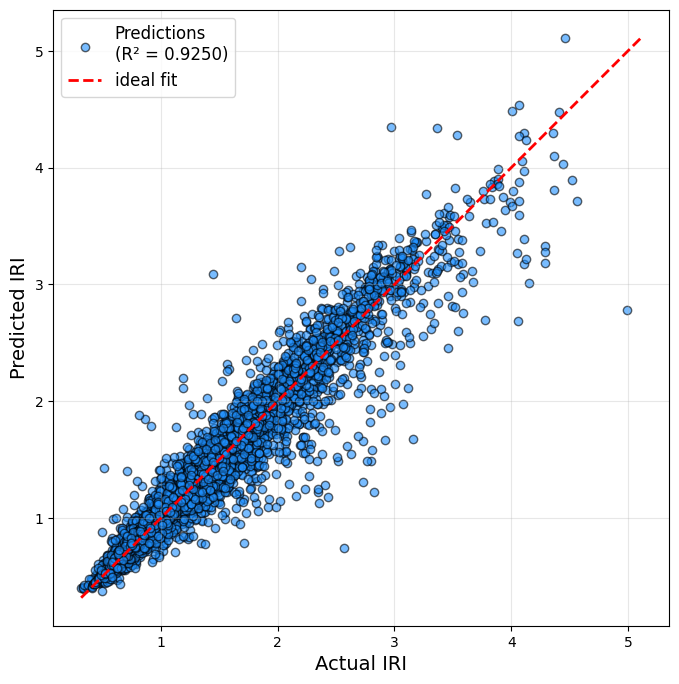

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

r2 = r2_score(y_train_tensor, test_outputs)

# r3 = r2**3  # Cube of R²

print(f'R² Score: {r2:.4f}')
#print RMSE
print(f'RMSE: {np.sqrt(np.mean((y_train_tensor - test_outputs)**2)):.4f}')

# Create figure
plt.figure(figsize=(8, 8))  # Ensure a square plot
plt.scatter(y_train_tensor, test_outputs, alpha=0.6, edgecolors="black", color="dodgerblue", label=f"Predictions\n(R² = {r2:.4f})")

# Strong red diagonal line from (min, min) to (max, max)
min_val = min(y_train_tensor.min(), test_outputs.min())
max_val = max(y_train_tensor.max(), test_outputs.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
         label=f'ideal fit')

# Labels and Title
plt.xlabel('Actual IRI', fontsize=14)
plt.ylabel('Predicted IRI', fontsize=14)
# plt.title('Predicted vs Actual IRI', fontsize=16)
plt.legend(fontsize=12, loc='upper left')

# Grid and Aspect Ratio
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')  # Perfect square plot

# Show the plot
plt.show()



In [ ]:
best_model.eval()
with torch.no_grad():
    predictions = best_model(X_test_tensor)
    # final_test_loss = criterion(predictions, y_test_tensor).item()

    final_test_loss = criterion(predictions, y_test_tensor).item()


print("Final Test Loss:", final_test_loss)
test_outputs = predictions.cpu().numpy()
y_test_tensor = y_test_tensor.cpu().numpy()
# y_train_tensor = y_train_tensor.cpu().numpy()

test_outputs = lstm_scaler_target.inverse_transform(test_outputs)
y_test_tensor = lstm_scaler_target.inverse_transform(y_test_tensor)
# y_train_tensor = lstm_scaler_target.inverse_transform(y_train_tensor)


# Square the values
test_outputs = np.square(test_outputs)
y_test_tensor = np.square(y_test_tensor)
# y_train_tensor = np.square(y_train_tensor)

Final Test Loss: 0.02207811176776886


R² Score: 0.9277
RMSE: 0.1363


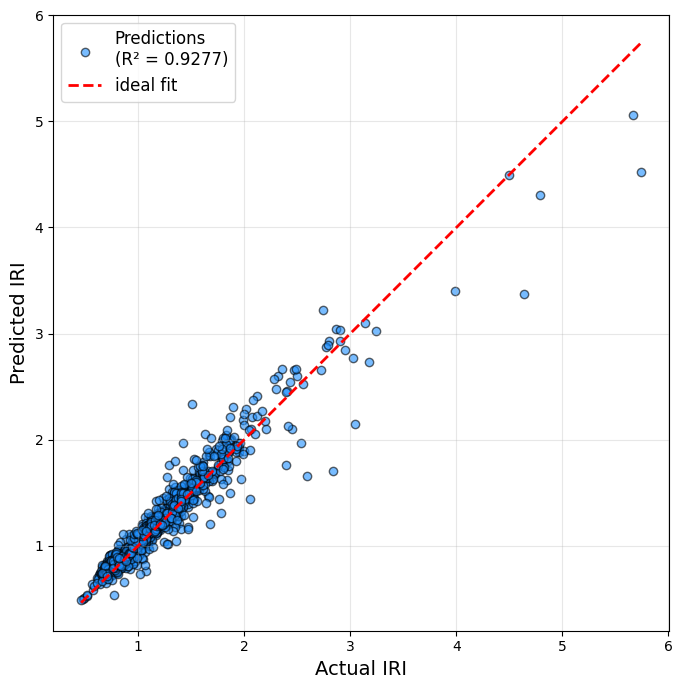

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

r2 = r2_score(y_test_tensor, test_outputs)

# r3 = r2**3  # Cube of R²

print(f'R² Score: {r2:.4f}')
#print RMSE
print(f'RMSE: {np.sqrt(np.mean((y_test_tensor - test_outputs)**2)):.4f}')

# Create figure
plt.figure(figsize=(8, 8))  # Ensure a square plot
plt.scatter(y_test_tensor, test_outputs, alpha=0.6, edgecolors="black", color="dodgerblue", label=f"Predictions\n(R² = {r2:.4f})")

# Strong red diagonal line from (min, min) to (max, max)
min_val = min(y_test_tensor.min(), test_outputs.min())
max_val = max(y_test_tensor.max(), test_outputs.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
         label=f'ideal fit')

# Labels and Title
plt.xlabel('Actual IRI', fontsize=14)
plt.ylabel('Predicted IRI', fontsize=14)
# plt.title('Predicted vs Actual IRI', fontsize=16)
plt.legend(fontsize=12, loc='upper left')

# Grid and Aspect Ratio
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')  # Perfect square plot

# Show the plot
plt.show()

In [ ]:
#save the model weight, featujres, and standardizers
import torch

# Save model weights
torch.save(best_model.state_dict(), "models_07_21/lstm_model.pth")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
with open("models_07_21/lstm_config.json", "w") as json_file:
    json.dump(lstm_features, json_file, indent=4)

print("JSON file saved successfully!")

JSON file saved successfully!


In [ ]:
import joblib

# Save the scalers
joblib.dump(lstm_scaler_features, "models_07_21/LSTM_scaler_features.joblib")
joblib.dump(lstm_scaler_target, "models_07_21/LSTM_scaler_target.joblib")
joblib.dump(lstm_scaler_age, "models_07_21/LSTM_scaler_age.joblib")

print("StandardScalers saved successfully!")

StandardScalers saved successfully!


## GENERAL TESTING

In [138]:
import os
# os.chdir("/content/drive/MyDrive/IowaDOT_IRI")

In [379]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
# import optuna
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
idx  = 14

Using device: cuda


In [380]:
#read pacquet dataframe_for_IRI_drop
# df = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop.parquet')
#read csv FINAL_DATASET_for_IRI_progression
df = pd.read_csv('processed_07_21/FINAL_DATASET_for_IRI_progression2.csv')

In [381]:
# Define LSTM Model (Must match the original architecture)

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# Load the best hyperparameters from JSON
with open("models_07_21/lstm_features.json", "r") as json_file:
    lstm_features = json.load(json_file)


# Initialize model with best parameters
best_params = lstm_features['best_params']
input_dim = 14 # Should match the number of features
hidden_dim = best_params['hidden_dim']
output_dim = 1  # Single output (e.g., regression)
num_layers = best_params['num_layers']

lstm_model = LSTMModel(input_dim, hidden_dim, output_dim, num_layers).to(device)

# Load the trained weights
lstm_model.load_state_dict(torch.load("models_07_21/lstm_model.pth"))
lstm_model.eval()  # Set model to evaluation mode

print("✅ LSTM Model loaded successfully!")

import joblib

# Load the saved StandardScaler objects
lstm_scaler_features = joblib.load("models_07_21/LSTM_scaler_features.joblib")
lstm_scaler_target = joblib.load("models_07_21/LSTM_scaler_target.joblib")
lstm_scaler_age = joblib.load("models_07_21/LSTM_scaler_age.joblib")

print("✅ StandardScalers loaded successfully!")


✅ LSTM Model loaded successfully!
✅ StandardScalers loaded successfully!


/tmp/ipykernel_3909/1278158988.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_model.load_state_dict(torch.load("models_07_21/lstm_model.pth"))
/home/oguntoye/mini

### internal jargons

In [382]:
test = df[df.STATE_CODE == 19]

In [383]:
srt_feaures = ['FREEZE_INDEX', 'H_AC', 'MRI', 'AGE']
log_features = ['AADTT', 'H_TOT',  'Days_since_last_MRI']
boolean_features = ['Eng_Fab', 'Treated_Base', 'Treated_Subbase']

#apply the transformations
test[srt_feaures] = np.sqrt(test[srt_feaures])
test[log_features] = np.log1p(test[log_features])
test[boolean_features] = test[boolean_features].astype(int)
test['REL_HUM_AVG_AVG'] = np.log1p(lstm_features['humididty_max'] - test['REL_HUM_AVG_AVG'])

/tmp/ipykernel_3909/1904135124.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[srt_feaures] = np.sqrt(test[srt_feaures])
/tmp/ipykernel_3909/1904135124.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[log_features] = np.log1p(test[log_features])
/tmp/ipykernel_3909/1904135124.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

In [384]:
feature_cols = lstm_features['LSTM_features']
test[feature_cols] = lstm_scaler_features.transform(test[feature_cols])
test['MRI'] = lstm_scaler_target.transform(test[['MRI']])
test['AGE'] = lstm_scaler_age.transform(test[['AGE']])

/tmp/ipykernel_3909/1347549236.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[feature_cols] = lstm_scaler_features.transform(test[feature_cols])
/tmp/ipykernel_3909/1347549236.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['MRI'] = lstm_scaler_target.transform(test[['MRI']])
/tmp/ipykernel_3909/1347549236.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

In [385]:
test.head()

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG,AADTT,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,Days_since_last_MRI
3749,19,0101,2,1993,1993-10-15,-0.046595,1.471212,-0.578148,0.699576,0.397109,-2.063166,-2.441562,-2.395577,0.369283,0,0,0,1.497191,-2.836410
3750,19,0101,2,1995,1995-02-15,0.227123,0.452850,-0.480512,0.695761,0.397109,-0.589016,-1.666862,-1.905310,0.369283,0,0,0,1.497191,0.362340
3751,19,0101,2,1996,1996-04-16,0.479734,0.461238,-0.513057,0.761365,0.758318,-0.151773,-1.382446,-1.707735,0.369283,0,0,0,1.497191,0.292305
3752,19,0101,2,1997,1997-09-25,0.591137,0.175243,-0.382875,0.516488,0.871196,-0.151773,-1.139810,-1.529114,0.369283,0,0,0,1.497191,0.401978
3753,19,0101,2,1998,1998-10-13,0.752654,0.654088,-0.122511,0.235322,0.171353,-0.857211,-0.967388,-1.364855,0.369283,0,0,0,1.497191,0.237476


In [386]:
#read pacquet dataframe_for_IRI_drop
# df_total = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop.parquet')
# df_total = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop_256.parquet')
# df_total = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop_1536.parquet')
# df_total = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop_256L.parquet')
# df_total = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop_512L.parquet')
# df_total = pd.read_parquet('processed_07_21/dataframe_for_IRI_drop_3KL.parquet')


#read embed_df
embed_df = pd.read_parquet('DATA_07_26/maintenance_embeddings.parquet')
tmp_df = embed_df.iloc[:, [0, idx]]
embed_col = tmp_df.columns[1]

print(embed_col)
size = embed_col.split('_')[1]
print(size)

# print(size)
#read the parque tsing the embed_col ref
df_total = pd.read_parquet(f'DATA_07_26/dataframe_for_IRI_drop_{embed_col}.parquet')

text-embedding-3-large_256
256


In [387]:
df_total = df_total[df_total.STATE_CODE == 19]
test_total = df_total.drop(columns = ['YEAR', 'MAINTENANCE'])

In [388]:
class DualBranchNN(nn.Module):
    def __init__(self, input_size_numeric, input_size_text, best_params):
        super(DualBranchNN, self).__init__()

        # Optimized text processing branch
        self.text_branch = nn.Sequential(
            nn.Linear(input_size_text, best_params["reduced_text_size"]),
            nn.ReLU(),
            nn.Dropout(best_params["dropout_text"])
        )

        # Optimized structured data branch
        self.numeric_branch = nn.Sequential(
            nn.Linear(input_size_numeric, best_params["numeric_hidden_size"]),
            nn.ReLU(),
            nn.Dropout(best_params["dropout_numeric"])
        )

        # Optimized merged final layer
        self.final_layer = nn.Sequential(
            nn.Linear(best_params["reduced_text_size"] + best_params["numeric_hidden_size"],
                      best_params["final_hidden_size"]),
            nn.ReLU(),
            nn.Linear(best_params["final_hidden_size"], 1)
        )

    def forward(self, text_embedding, numeric_features):
        text_out = self.text_branch(text_embedding)
        num_out = self.numeric_branch(numeric_features)
        combined = torch.cat((text_out, num_out), dim=1)
        output = self.final_layer(combined)
        return output


In [389]:
import json
#CHANGE HERE

with open(f"models_07_26/{embed_col}/ANN_features.json", "r") as json_file:
    ANN_features = json.load(json_file)

# Instantiate model with the correct input sizes
best_params = ANN_features['best_params']

input_size_numeric = 10
input_size_text = eval(size)

ann_model = DualBranchNN(input_size_numeric, input_size_text, best_params).to(device)

# Load the saved weights
ann_model.load_state_dict(torch.load(f"models_07_26/{embed_col}/DualBranchNN_model.pth"))
ann_model.eval()  # Set to evaluation mode

print("✅ DualBranchNN model loaded successfully!")

✅ DualBranchNN model loaded successfully!


/tmp/ipykernel_3909/3975105291.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ann_model.load_state_dict(torch.load(f"models_07_26/{embed_col}/DualBranchNN_model.pth"))

In [390]:
def transform(df_total):
    sqrt_transform = [ 'H_AC', 'AGE', 'DAYS_SINCE_MAINTENANCE' ]
    log_transform = ['H_TOT', 'MRI_BEFORE', 'MRI_AFTER', 'AADTT',  'Added_Thickness']
    booleans = ['Eng_Fab', 'Treated_Base', 'Treated_Subbase']

    # Apply square root transformation (avoid NaN for negative values)
    for feature in sqrt_transform:
        df_total[feature] = np.sqrt(df_total[feature])  # Ensure non-negative values

    # Apply log transformation (avoid NaN for negative values)
    for feature in log_transform:
        df_total[feature] = np.log1p(df_total[feature].clip(0, None))  # Ensure non-negative values
        df_total[feature] = df_total[feature].fillna(0)  # Fill NaNs with 0 (if any)

    # Apply integer conversion to booleans (ensure only 0 and 1)
    for feature in booleans:
        df_total[feature] = df_total[feature].astype(bool).astype(int)

    return df_total

In [391]:
import joblib
#CHANGE

# Load the saved StandardScaler objects
ann_scaler_features = joblib.load(f"models_07_26/{embed_col}/ANN_standardizer_features.joblib")
ann_scaler_target = joblib.load(f"models_07_26/{embed_col}/ANN_standardizer_target.joblib")


print("✅ StandardScalers loaded successfully!")

✅ StandardScalers loaded successfully!


In [392]:
ann_scaler_features.feature_names_in_

array(['AGE', 'H_AC', 'H_TOT', 'MRI_BEFORE', 'DAYS_SINCE_MAINTENANCE',
       'Added_Thickness', 'AADTT'], dtype=object)

In [393]:
unit = test.groupby(['STATE_CODE', 'SHRP_ID'])['MRI'].count().reset_index()

# unit['MRI'].value_counts()

pavement_section = unit.sort_values(by = 'MRI', ascending=False)
# pavement_section = pavement_section.iloc[0:1, :]
pavement_section

,STATE_CODE,SHRP_ID,MRI
15,19,6150,14
13,19,1044,12
2,19,0103,11
1,19,0102,11
0,19,0101,11
4,19,0105,11
3,19,0104,11
5,19,0106,11
7,19,0108,11
8,19,0109,11


In [394]:
def sequence_test(df, sql, dt = 1, X_test = [], y_test = []):
    sections = df.groupby(['STATE_CODE', 'SHRP_ID']).size().reset_index(name='count')
    for _, row in sections.iterrows():
        state = row['STATE_CODE']
        shrp = row['SHRP_ID']

        data = df[(df['STATE_CODE'] == state) & (df['SHRP_ID'] == shrp)]
        #sort data by year
        data = data.sort_values(by='YEAR_VISITED')

        n = len(data)
        l = 0
        r = l + sql - 1
        if len(data) > sql:
            while r < n - 1:
                x_data = data.iloc[l:r + 1, :]
                next_data = data.iloc[r + 1, :]

                if next_data['CONSTRUCTION_NO'] == x_data.iloc[-1].CONSTRUCTION_NO:
                    X_test.append(x_data.iloc[:, 5:])
                    y_test.append(next_data['MRI'])

                l += dt
                r += dt

                if r == n - 1:
                    x_data = data.iloc[l:r + 1, :]
                    if x_data.iloc[-sql].CONSTRUCTION_NO == x_data.iloc[-1].CONSTRUCTION_NO:
                        X_test.append(x_data.iloc[:, 5:])
                        # y_test.append(0)
        else:
            continue
    return np.array(X_test), np.array(y_test)

In [395]:
state = 19
shrp = '0105'
use = test[(test['STATE_CODE'] == state) & (test['SHRP_ID'] == shrp)].copy()
# use


In [396]:
use

,STATE_CODE,SHRP_ID,CONSTRUCTION_NO,YEAR_VISITED,VISIT_DATE,MRI,PRECIPITATION,TEMP_MEAN_AVG,FREEZE_INDEX,FREEZE_THAW,REL_HUM_AVG_AVG,AADTT,AGE,H_AC,Eng_Fab,Treated_Base,Treated_Subbase,H_TOT,Days_since_last_MRI
3793,19,0105,2,1993,1993-10-15,-0.359130,1.471212,-0.578148,0.699576,0.397109,-2.063166,-2.441562,-2.395577,-1.06113,0,1,0,1.23225,-2.836410
3794,19,0105,2,1995,1995-02-15,-0.156703,0.452850,-0.480512,0.695761,0.397109,-0.589016,-1.666862,-1.905310,-1.06113,0,1,0,1.23225,0.362340
3795,19,0105,2,1996,1996-04-16,0.217662,0.461238,-0.513057,0.761365,0.758318,-0.151773,-1.382446,-1.707735,-1.06113,0,1,0,1.23225,0.292305
3796,19,0105,2,1997,1997-09-25,0.234073,0.175243,-0.382875,0.516488,0.871196,-0.151773,-1.139810,-1.529114,-1.06113,0,1,0,1.23225,0.401978
3797,19,0105,2,1998,1998-10-13,0.275384,0.654088,-0.122511,0.235322,0.171353,-0.857211,-0.967388,-1.364855,-1.06113,0,1,0,1.23225,0.237476
3798,19,0105,2,1999,1999-07-19,0.379827,-0.421292,-0.187602,0.335470,0.622864,-0.057705,-0.805177,-1.211966,-1.06113,0,1,0,1.23225,0.074318
3799,19,0105,2,2000,2000-05-22,0.395183,-0.379860,-0.220148,0.666870,0.374533,0.116423,-0.669733,-1.068370,-1.06113,0,1,0,1.23225,0.125226
3800,19,0105,2,2001,2001-05-29,0.795061,0.461414,-0.236420,0.426520,0.487411,-0.356695,-0.550811,-0.932554,-1.06113,0,1,0,1.23225,0.222463
3801,19,0105,3,2001,2001-08-06,0.411693,0.461414,-0.236420,0.426520,0.487411,-0.356695,-0.550811,-0.932554,-1.06113,0,1,0,1.23225,-0.641791
3802,19,0105,3,2002,2002-11-22,0.433793,-0.319892,-0.236420,0.157465,1.096952,-0.251218,-0.450430,-0.803375,-1.06113,0,1,0,1.23225,0.346246


## internal process

In [305]:
diff_list = []

for idx, row in pavement_section.iterrows():
    state = row['STATE_CODE']
    shrp = row['SHRP_ID']
    use = test[(test['STATE_CODE'] == state) & (test['SHRP_ID'] == shrp)].copy()

    if use.empty:
        print(f"Skipping {state}_{shrp} due to no data")
        continue


    # LSTM sequence generation
    input_seq = []
    target_seq = []
    input_seq, target_seq = sequence_test(use, 1, 1, input_seq, target_seq)
    # print(f"[{state}_{shrp}] Input Sequence Length: {len(input_seq)}")

    use['AGE_'] = lstm_scaler_age.inverse_transform(use[['AGE']])
    use['AGE_'] = use['AGE_'] ** 2
    use['AGE_'] = use['AGE_'].round(0)

    use['NEXT_CONSTRUCTION_NO'] = use['CONSTRUCTION_NO'].shift(1).fillna(use['CONSTRUCTION_NO'].iloc[0])

    Age = []
    activity = []
    age_activity = []
    maintenance = []
    drop_age = []

    prev = None
    for _, row_inner in use.iterrows():
        if row_inner['CONSTRUCTION_NO'] == row_inner['NEXT_CONSTRUCTION_NO']:
            Age.append(int(row_inner['AGE_']))
            prev = int(row_inner['AGE_'])
            age_activity.append(prev)
            activity.append('False')
        else:
            print(f"New maintenance activity in year: {row_inner['YEAR_VISITED']}")
            activity.append('True')
            try:
                m_val = df_total[(df_total.AGE == prev) & (df_total.SHRP_ID == shrp)]['MAINTENANCE'].values[0]
                maintenance.append(m_val)
                age_activity.append(int(row_inner['AGE_']))
                drop_age.append(prev)
            except Exception as e:
                print(f"Could not find maintenance info for {shrp} at AGE {prev}: {e}")

    if Age:
        Age.append(Age[-1] + 1)

    # LSTM Prediction
    with torch.no_grad():
        output_tensor = lstm_model(torch.tensor(input_seq, dtype=torch.float32).to(device))

        test_outputs = output_tensor.cpu().numpy()
        # print(f"[{state}_{shrp}] Output Sequence Length: {len(test_outputs)}")

    # Fix length mismatch
    first_val = input_seq[0][0][0]
    target_seq = np.insert(target_seq, 0, first_val)

    output_vals = lstm_scaler_target.inverse_transform(test_outputs)
    target_vals = lstm_scaler_target.inverse_transform(target_seq.reshape(-1, 1))

    output_vals = output_vals ** 2
    target_vals = target_vals ** 2

    # ANN Processing
    test_drop = test_total[(test_total.AGE.isin(drop_age)) & (test_total.SHRP_ID == shrp)]
    test_drop = transform(test_drop)
    # print(test_drop)
    if test_drop.empty:
        continue
    def standardize(data):
      data[ANN_features['ann_features']] = ann_scaler_features.transform(data[ANN_features['ann_features']])
      data['MRI_AFTER'] = ann_scaler_target.transform(data[['MRI_AFTER']])

      return data

    test_drop = standardize(test_drop)
    # print(test_drop)
    features = ANN_features['ann_features'] + ["Eng_Fab", "Treated_Base", "Treated_Subbase"]

    target_col = "MRI_AFTER"
    feature_cols_text = test_drop.columns[13:]
    X_train_struct = test_drop[features]  # Drop MRI
    X_train_text = test_drop[feature_cols_text]
    y_train = test_drop[target_col]
    # Convert already preprocessed data to PyTorch tensors

    # print(X_train_struct)
    numeric_tensor = torch.tensor(X_train_struct.values, dtype=torch.float32).to(device)
    text_tensor = torch.tensor(X_train_text.values, dtype=torch.float32).to(device)

    # Perform batch prediction
    with torch.no_grad():
        # print('here')
        predictions = ann_model(text_tensor, numeric_tensor)

    # Convert predictions to NumPy
    predicted_values = predictions.cpu().numpy().flatten()

    print(f"[{state}_{shrp}] Predicted Sequence Length: {len(predicted_values)}")

    # Inverse transform the predicted and actual values
    actual_values = ann_scaler_target.inverse_transform(y_train.values.reshape(-1, 1)).flatten()
    predicted_values = ann_scaler_target.inverse_transform(predicted_values.reshape(-1, 1)).flatten()

    #inverlog
    predicted_values = np.expm1(predicted_values)
    actual_values = np.expm1(actual_values)

    avg_drop_diff = np.mean(np.abs(predicted_values - actual_values))

            # Save result
    diff_list.append({
        "PAVEMENT_SECTION": f"{state}_{shrp}",
        "PREDICTED_IRI": predicted_values.tolist(),
        "ACTUAL_IRI": actual_values.tolist(),
        "AVG_ABS_DIFF": avg_drop_diff
    })

    # except Exception as e:
    #     print(f"Error processing {state}_{shrp}: {e}")
    #     continue

        # Final summary DataFrame
diff_df = pd.DataFrame(diff_list)




New maintenance activity in year: 1998
[19_6150] Predicted Sequence Length: 1
New maintenance activity in year: 1992
New maintenance activity in year: 1997
Could not find maintenance info for 1044 at AGE 24: index 0 is out of bounds for axis 0 with size 0
New maintenance activity in year: 2003
New maintenance activity in year: 2020
[19_1044] Predicted Sequence Length: 2
New maintenance activity in year: 2001
[19_0103] Predicted Sequence Length: 1
New maintenance activity in year: 2001
[19_0102] Predicted Sequence Length: 1
New maintenance activity in year: 2001
[19_0101] Predicted Sequence Length: 1
New maintenance activity in year: 2001
[19_0105] Predicted Sequence Length: 1
New maintenance activity in year: 2001
[19_0104] Predicted Sequence Length: 1
New maintenance activity in year: 2001
[19_0106] Predicted Sequence Length: 1
New maintenance activity in year: 2001
[19_0108] Predicted Sequence Length: 1
New maintenance activity in year: 2001
[19_0109] Predicted Sequence Length: 1
New

/tmp/ipykernel_3909/455311213.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total[feature] = np.sqrt(df_total[feature])  # Ensure non-negative values
/tmp/ipykernel_3909/455311213.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total[feature] = np.log1p(df_total[feature].clip(0, None))  # Ensure non-negative values
/tmp/ipykernel_3909/455311213.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

New maintenance activity in year: 2001
[19_0107] Predicted Sequence Length: 1
New maintenance activity in year: 1993
Could not find maintenance info for 6049 at AGE 31: index 0 is out of bounds for axis 0 with size 0
New maintenance activity in year: 1997
New maintenance activity in year: 1999
[19_6049] Predicted Sequence Length: 2
New maintenance activity in year: 2001
[19_0112] Predicted Sequence Length: 1
New maintenance activity in year: 2004
[19_0159] Predicted Sequence Length: 1
New maintenance activity in year: 1991
[19_A310] Predicted Sequence Length: 1
New maintenance activity in year: 1991
[19_A320] Predicted Sequence Length: 1
New maintenance activity in year: 1991
[19_A330] Predicted Sequence Length: 1
New maintenance activity in year: 1991
[19_A350] Predicted Sequence Length: 1


/tmp/ipykernel_3909/455311213.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total[feature] = np.sqrt(df_total[feature])  # Ensure non-negative values
/tmp/ipykernel_3909/455311213.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total[feature] = np.log1p(df_total[feature].clip(0, None))  # Ensure non-negative values
/tmp/ipykernel_3909/455311213.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [306]:

# Optional: Save to file
diff_df.to_csv("avg_abs_diff_per_section.csv", index=False)
diff_df

,PAVEMENT_SECTION,PREDICTED_IRI,ACTUAL_IRI,AVG_ABS_DIFF
0,19_6150,[0.5365546345710754],[0.47670000493526465],0.059855
1,19_1044,"[2.0810046195983887, 4.167105197906494]","[1.7359999775886532, 0.5258999943733216]",1.993105
2,19_0103,[1.5871247053146362],[1.5162999868392943],0.070825
3,19_0102,[2.706731081008911],[2.489599990844726],0.217131
4,19_0101,[2.1968631744384766],[1.8355999946594241],0.361263
5,19_0105,[1.8817816972732544],[1.4460999965667722],0.435682
6,19_0104,[1.54812490940094],[1.330399990081787],0.217725
7,19_0106,[1.4626775979995728],[1.3090999960899352],0.153578
8,19_0108,[1.982075810432434],[1.606700026988983],0.375376
9,19_0109,[0.8507260084152222],[1.1692999958992003],0.318574


In [307]:
input = []
target = []
use = test[(test['STATE_CODE'] == state) & (test['SHRP_ID'] == shrp)].copy()
input, target = sequence_test(use,1,1, input, target)


use['AGE_'] = lstm_scaler_age.inverse_transform(use[['AGE']])
use['AGE_'] = use['AGE_'] ** 2  # Square AGE_

#use AGE_ rount to the whole number
use['AGE_'] = use['AGE_'].round(0)
# use['AGE_'] = use['AGE_'].


use['NEXT_CONSTRUCTION_NO'] = use['CONSTRUCTION_NO'].shift(1)
use['NEXT_CONSTRUCTION_NO'] = use['NEXT_CONSTRUCTION_NO'].fillna(use['CONSTRUCTION_NO'].iloc[0])

Age = []
activity = []
age_activity = []
maintenance = []
drop_age = []
for _, row in use.iterrows():
    if row['CONSTRUCTION_NO'] == row['NEXT_CONSTRUCTION_NO']:
        Age.append(int(row['AGE_']))
        prev = int(row['AGE_'])
        age_activity.append(int(row['AGE_']))
        activity.append('False')  # Convert to int correctly
    else:
        print(row['YEAR_VISITED'])
        activity.append('True')
        try:

            maintenance.append(df_total[(df_total.AGE == prev) &\
                                       (df_total.SHRP_ID == shrp)]['MAINTENANCE'].values[0])
            age_activity.append(int(row['AGE_']))
            drop_age.append(prev)
        except:
            pass
        curr = prev


Age.append(Age[-1] + 1)

with torch.no_grad():
    print(input.shape)
    output = lstm_model(torch.tensor(input, dtype=torch.float32).to(device))
    test_outputs = output.cpu().numpy()


#get first element in o
first = input[0][0][0]
# second = o[0][1][0]

#insert in p
target = np.insert(target, 0, first)
# p = np.insert(p, 1, second)

#inverse output and p
output = lstm_scaler_target.inverse_transform(test_outputs)
target = lstm_scaler_target.inverse_transform(target.reshape(-1, 1))

#square
output = output**2
target = target**2
# append 0 to p
len(output), len(target), len(Age), len(activity), len(input)

test_drop = test_total[(test_total.AGE.isin(drop_age)) & (test_total.SHRP_ID == shrp)]
test_drop = transform(test_drop)
def standardize(data):
    data[ANN_features['ann_features']] = ann_scaler_features.transform(data[ANN_features['ann_features']])
    data['MRI_AFTER'] = ann_scaler_target.transform(data[['MRI_AFTER']])

    return data

test_drop = standardize(test_drop)
features = ANN_features['ann_features'] + ["Eng_Fab", "Treated_Base", "Treated_Subbase"]

target_col = "MRI_AFTER"
feature_cols_text = test_drop.columns[13:]
X_train_struct = test_drop[features]  # Drop MRI
X_train_text = test_drop[feature_cols_text]
y_train = test_drop[target_col]
# Convert already preprocessed data to PyTorch tensors
print(X_train_struct)
numeric_tensor = torch.tensor(X_train_struct.values, dtype=torch.float32).to(device)
text_tensor = torch.tensor(X_train_text.values, dtype=torch.float32).to(device)

# Perform batch prediction
with torch.no_grad():
    predictions = ann_model(text_tensor, numeric_tensor)

# Convert predictions to NumPy
predicted_values = predictions.cpu().numpy().flatten()

# Inverse transform the predicted and actual values
actual_values = ann_scaler_target.inverse_transform(y_train.values.reshape(-1, 1)).flatten()
predicted_values = ann_scaler_target.inverse_transform(predicted_values.reshape(-1, 1)).flatten()

# Create a DataFrame for easy visualization
predictions_df = pd.DataFrame({
    "Actual": actual_values,
    "Predicted": predicted_values
})
predictions_df
avg_drop_diff = np.mean(np.abs(predicted_values - actual_values))

1991
(3, 1, 14)
          AGE     H_AC     H_TOT  MRI_BEFORE  DAYS_SINCE_MAINTENANCE  \
449  1.816096 -0.73782 -1.306177    0.162618                1.466317   

     Added_Thickness     AADTT  Eng_Fab  Treated_Base  Treated_Subbase  
449         0.268072 -0.939618        0             1                0  


/tmp/ipykernel_3909/455311213.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total[feature] = np.sqrt(df_total[feature])  # Ensure non-negative values
/tmp/ipykernel_3909/455311213.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_total[feature] = np.log1p(df_total[feature].clip(0, None))  # Ensure non-negative values
/tmp/ipykernel_3909/455311213.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [308]:
input.shape

(3, 1, 14)

### ORIGINAL_END

## Test

In [397]:
diff_list = []

for idx, row in pavement_section.iterrows():
    state = row['STATE_CODE']
    shrp = row['SHRP_ID']
    use = test[(test['STATE_CODE'] == state) & (test['SHRP_ID'] == shrp)].copy()

    if use.empty:
        print(f"Skipping {state}_{shrp} due to no data")
        continue

    # LSTM sequence generation
    input_seq = []
    target_seq = []
    input_seq, target_seq = sequence_test(use, 1, 1, input_seq, target_seq)

    use.loc[:, 'AGE_'] = lstm_scaler_age.inverse_transform(use[['AGE']])
    use.loc[:, 'AGE_'] = use['AGE_'] ** 2
    use.loc[:, 'AGE_'] = use['AGE_'].round(0)

    use.loc[:, 'NEXT_CONSTRUCTION_NO'] = use['CONSTRUCTION_NO'].shift(1).fillna(use['CONSTRUCTION_NO'].iloc[0])

    Age = []
    activity = []
    age_activity = []
    maintenance = []
    drop_age = []

    prev = None
    for _, row_inner in use.iterrows():
        if row_inner['CONSTRUCTION_NO'] == row_inner['NEXT_CONSTRUCTION_NO']:
            Age.append(int(row_inner['AGE_']))
            prev = int(row_inner['AGE_'])
            age_activity.append(prev)
            activity.append('False')
        else:
            print(f"New maintenance activity in year: {row_inner['YEAR_VISITED']}")
            activity.append('True')
            try:
                m_val = df_total.loc[(df_total.AGE == prev) & (df_total.SHRP_ID == shrp), 'MAINTENANCE'].values[0]
                maintenance.append(m_val)
                age_activity.append(int(row_inner['AGE_']))
                drop_age.append(prev)
            except Exception as e:
                print(f"Could not find maintenance info for {shrp} at AGE {prev}: {e}")

    if Age:
        Age.append(Age[-1] + 1)

    # LSTM Prediction
    with torch.no_grad():
        output_tensor = lstm_model(torch.tensor(input_seq, dtype=torch.float32).to(device))
        test_outputs = output_tensor.cpu().numpy()

    first_val = input_seq[0][0][0]
    target_seq = np.insert(target_seq, 0, first_val)

    output_vals = lstm_scaler_target.inverse_transform(test_outputs)
    target_vals = lstm_scaler_target.inverse_transform(target_seq.reshape(-1, 1))

    output_vals = output_vals ** 2
    target_vals = target_vals ** 2

    # ANN Section
    test_drop = test_total.loc[(test_total.AGE.isin(drop_age)) & (test_total.SHRP_ID == shrp)].copy()
    if test_drop.empty:
        continue

    def standardize(data):
        data.loc[:, ANN_features['ann_features']] = ann_scaler_features.transform(data[ANN_features['ann_features']])
        data.loc[:, 'MRI_AFTER'] = ann_scaler_target.transform(data[['MRI_AFTER']])
        return data

    test_drop = transform(test_drop)
    test_drop = standardize(test_drop)

    features = ANN_features['ann_features'] + ["Eng_Fab", "Treated_Base", "Treated_Subbase"]
    target_col = "MRI_AFTER"
    feature_cols_text = test_drop.columns[13:]

    X_train_struct = test_drop[features]
    X_train_text = test_drop[feature_cols_text]
    y_train = test_drop[target_col]

    numeric_tensor = torch.tensor(X_train_struct.values, dtype=torch.float32).to(device)
    text_tensor = torch.tensor(X_train_text.values, dtype=torch.float32).to(device)

    with torch.no_grad():
        predictions = ann_model(text_tensor, numeric_tensor)

    predicted_values = predictions.cpu().numpy().flatten()
    actual_values = ann_scaler_target.inverse_transform(y_train.values.reshape(-1, 1)).flatten()
    predicted_values = ann_scaler_target.inverse_transform(predicted_values.reshape(-1, 1)).flatten()

    predicted_values = np.expm1(predicted_values)
    actual_values = np.expm1(actual_values)

    avg_diff_pred = np.mean(np.abs(output_vals[:-1] - target_vals[1:]))
    avg_drop_diff = np.mean(np.abs(predicted_values - actual_values))

    diff_list.append({
        "PAVEMENT_SECTION": f"{state}_{shrp}",
        # "AVG_DIFF_PRED": avg_diff_pred,
        "actual_values": actual_values.tolist(),
        "predicted_values": predicted_values.tolist(),
        "AVG_ABS_DIFF": avg_drop_diff
    })

    # Plotting
    # plt.figure(figsize=(10, 6))

    # # Plot LSTM predictions
    # plt.plot(Age[:-1], target_vals, 'bo', label='Actual IRI Projection', markersize=6, linestyle='None')
    # plt.plot(Age[1:], output_vals, 'ro', label=f'Predicted IRI Projections (Avg Diff: {avg_diff_pred:.4f})', markersize=6, linestyle='None')

    # y_min, y_max = 0, max(max(target_vals), max(output_vals)) + 1
    # min_len = min(len(activity), len(drop_age), len(maintenance))

    # for i in range(min_len):
    #     drop_x = drop_age[i] + 1
    #     plt.axvline(x=drop_x, color='r', linestyle='--', linewidth=1.5)

    #     try:
    #         actual_val = actual_values[i]
    #         predicted_val = predicted_values[i]
    #     except:
    #         actual_val = predicted_val = y_min + 0.5

    #     plt.scatter(drop_x, actual_val, color='blue', marker='s', label="Actual IRI_drop" if i == 0 else "")
    #     plt.scatter(drop_x, predicted_val, color='red', marker='s',
    #                 label=f"Predicted IRI_drop (Avg. Diff: {avg_drop_diff:.2f})" if i == 0 else "")

    #     plt.text(drop_x + 0.5, actual_val, f"{actual_val:.2f}", fontsize=8, color='blue', ha='center')
    #     plt.text(drop_x + 0.5, predicted_val, f"{predicted_val:.2f}", fontsize=8, color='red', ha='center')

    #     maintenance_text = maintenance[i] if i < len(maintenance) else "Unknown"
    #     formatted_text = "\n".join(maintenance_text.split())

    #     text_y = actual_val + 0.6 if actual_val < (y_max - 1) else actual_val - 0.6
    #     text_x = drop_x - 0.3 if i % 2 == 0 else drop_x + 0.3

    #     plt.text(text_x, text_y, formatted_text,
    #              rotation=0, fontsize=8, ha='center', va='bottom',
    #              color='black', fontdict={'weight': 'bold'},
    #              bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4'))

    # plt.xticks(np.arange(min(Age), max(Age) + 1, step=1))
    # plt.yticks(np.arange(y_min, y_max, step=1))
    # plt.ylim(y_min, y_max)
    # plt.xlabel('Age')
    # plt.ylabel('IRI (m/km)')
    # plt.title(f'Actual vs Predicted with Maintenance Events: {state}_{shrp}')
    # plt.legend()
    # plt.grid(alpha=0.5)
    # plt.tight_layout()
    # plt.show()

# Final output
diff_df = pd.DataFrame(diff_list)


New maintenance activity in year: 1998
New maintenance activity in year: 1992
New maintenance activity in year: 1997
Could not find maintenance info for 1044 at AGE 24: index 0 is out of bounds for axis 0 with size 0
New maintenance activity in year: 2003
New maintenance activity in year: 2020
New maintenance activity in year: 2001
New maintenance activity in year: 2001
New maintenance activity in year: 2001
New maintenance activity in year: 2001
New maintenance activity in year: 2001
New maintenance activity in year: 2001
New maintenance activity in year: 2001
New maintenance activity in year: 2001
New maintenance activity in year: 2001
New maintenance activity in year: 2001
New maintenance activity in year: 2001
New maintenance activity in year: 1993
Could not find maintenance info for 6049 at AGE 31: index 0 is out of bounds for axis 0 with size 0
New maintenance activity in year: 1997
New maintenance activity in year: 1999
New maintenance activity in year: 2001
New maintenance acti

In [398]:
diff_df
col_to_deletd = ['19_1044', '19_6049']
diff_df = diff_df[~diff_df['PAVEMENT_SECTION'].isin(col_to_deletd)]
diff_df

,PAVEMENT_SECTION,actual_values,predicted_values,AVG_ABS_DIFF
0,19_6150,[0.47670000493526465],[0.8733240962028503],0.396624
2,19_0103,[1.5162999868392943],[1.391351342201233],0.124949
3,19_0102,[2.489599990844726],[2.395570755004883],0.094029
4,19_0101,[1.8355999946594241],[2.000730514526367],0.165131
5,19_0105,[1.4460999965667722],[1.7126758098602295],0.266576
6,19_0104,[1.330399990081787],[1.4125829935073853],0.082183
7,19_0106,[1.3090999960899352],[1.3409483432769775],0.031848
8,19_0108,[1.606700026988983],[1.8404756784439087],0.233776
9,19_0109,[1.1692999958992003],[1.0065306425094604],0.162769
10,19_0111,[1.230799996852875],[1.2630466222763062],0.032247


In [399]:
#get r2 
from sklearn.metrics import r2_score
r2 = r2_score(diff_df['actual_values'].explode(), diff_df['predicted_values'].explode())
print(f'R² Score: {r2:.4f}')

print(diff_df['AVG_ABS_DIFF'].mean())

R² Score: 0.7720
0.17007505148649216


In [63]:
#get MAE o
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(actual_values, predicted_values))

0.018072284382740333


In [65]:
actual_values

array([1.02614912])

ValueError: x and y must have same first dimension, but have shapes (3,) and (13, 1)

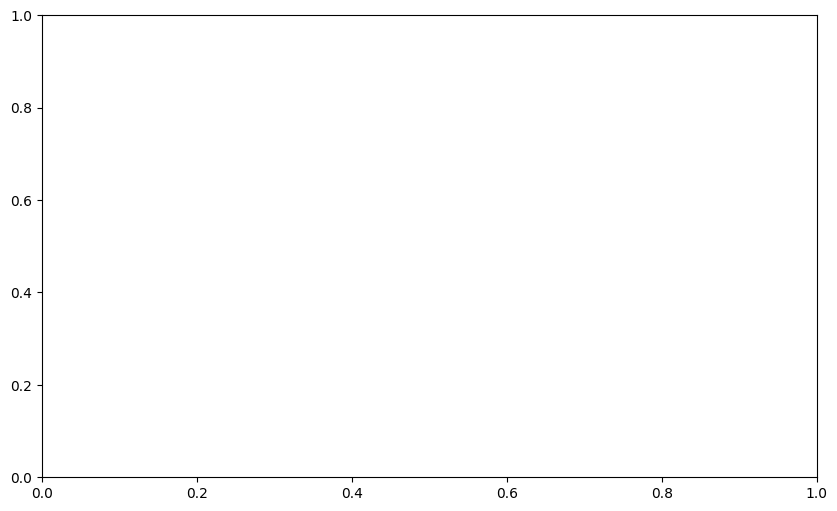

In [136]:
import matplotlib.pyplot as plt
import numpy as np

avg_diff_pred = np.mean(np.abs(output[:-1] - target[1:]))
avg_drop_diff = np.mean(np.abs(predicted_values - actual_values))

plt.figure(figsize=(10, 6))

# Scatter plot for Actual values
plt.plot(Age[:-1], target, 'bo', label='Actual IRI Projection', markersize=6, linestyle='None')

# Scatter plot for Predicted values
plt.plot(Age[1:], output, 'ro', label=f'Predicted IRI Projections (Avg Diff: {avg_diff_pred:.4f})', markersize=6, linestyle='None')

# Set plot limits
y_min, y_max = 0, max(max(target), max(output)) + 1

# Loop safely
min_len = min(len(activity), len(drop_age), len(maintenance))

for i in range(min_len):
    drop_x = drop_age[i] + 1
    plt.axvline(x=drop_x, color='r', linestyle='--', linewidth=1.5)

    # Retrieve actual and predicted values from predictions_df
    try:
        actual_value = predictions_df.iloc[i]["Actual"]
        predicted_value = predictions_df.iloc[i]["Predicted"]
    except:
        actual_value = predicted_value = y_min + 0.5  # fallback if missing

    # Drop points as square markers
    plt.scatter(drop_x, actual_value, color='blue', marker='s', label="Actual IRI_drop" if i == 0 else "")
    plt.scatter(drop_x, predicted_value, color='red', marker='s',
                label=f"Predicted IRI_drop (Avg. Diff: {avg_drop_diff:.2f})" if i == 0 else "")

    # Value labels next to drop points
    plt.text(drop_x + 0.5, actual_value, f"{actual_value:.2f}", fontsize=8, color='blue', ha='center')
    plt.text(drop_x + 0.5, predicted_value, f"{predicted_value:.2f}", fontsize=8, color='red', ha='center')

    # Maintenance annotation logic
    maintenance_text = maintenance[i] if i < len(maintenance) else "Unknown"
    formatted_text = "\n".join(maintenance_text.split())

    if actual_value < (y_max - 1):
        text_y = actual_value + 0.6
        va = 'bottom'
    else:
        text_y = actual_value - 0.6
        va = 'top'

    text_x = drop_x - 0.3 if i % 2 == 0 else drop_x + 0.3

    plt.text(text_x, text_y, formatted_text,
             rotation=0, fontsize=8, ha='center', va=va, color='black',
             fontdict={'weight': 'bold'},
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.4'))

# Axes and titles
plt.xticks(np.arange(min(Age), max(Age) + 1, step=1))
plt.yticks(np.arange(y_min, y_max, step=1))
plt.ylim(y_min, y_max)
plt.xlabel('Age')
plt.ylabel('IRI (m/km)')
plt.title(f'Actual vs Predicted with Connections for state {state} and SHRP {shrp}')
plt.legend()
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()


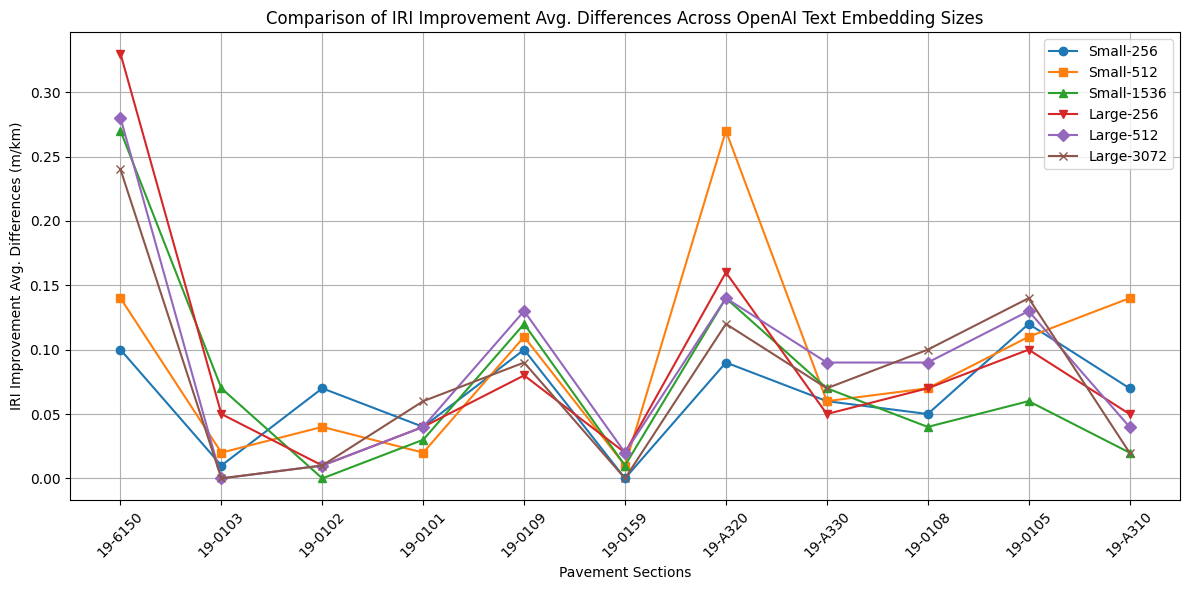

In [ ]:
import matplotlib.pyplot as plt

# Pavement sections
sections = [
    "19-6150", "19-0103", "19-0102", "19-0101", "19-0109", "19-0159",
    "19-A320", "19-A330", "19-0108", "19-0105", "19-A310"
]

# IRI improvement average differences
embedding_small_256 = [0.1, 0.01, 0.07, 0.04, 0.1, 0, 0.09, 0.06, 0.05, 0.12, 0.07]
embedding_small_512 = [0.14, 0.02, 0.04, 0.02, 0.11, 0.01, 0.27, 0.06, 0.07, 0.11, 0.14]
embedding_small_1536 = [0.27, 0.07, 0, 0.03, 0.12, 0.01, 0.14, 0.07, 0.04, 0.06, 0.02]
embedding_large_256 = [0.33, 0.05, 0.01, 0.04, 0.08, 0.02, 0.16, 0.05, 0.07, 0.1, 0.05]
embedding_large_512 = [0.28, 0, 0.01, 0.04, 0.13, 0.02, 0.14, 0.09, 0.09, 0.13, 0.04]
embedding_large_3072 = [0.24, 0, 0.01, 0.06, 0.09, 0, 0.12, 0.07, 0.1, 0.14, 0.02]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(sections, embedding_small_256, marker='o', label='Small-256')
plt.plot(sections, embedding_small_512, marker='s', label='Small-512')
plt.plot(sections, embedding_small_1536, marker='^', label='Small-1536')
plt.plot(sections, embedding_large_256, marker='v', label='Large-256')
plt.plot(sections, embedding_large_512, marker='D', label='Large-512')
plt.plot(sections, embedding_large_3072, marker='x', label='Large-3072')

plt.xlabel("Pavement Sections")
plt.ylabel("IRI Improvement Avg. Differences (m/km)")
plt.title("Comparison of IRI Improvement Avg. Differences Across OpenAI Text Embedding Sizes")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


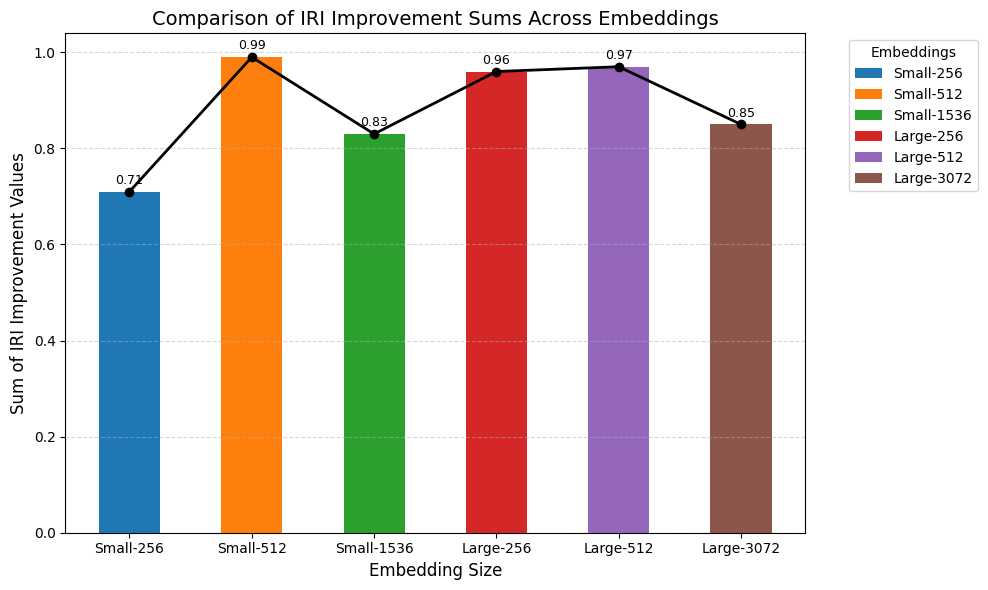

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Labels and sum values
embedding_labels = [
    "Small-256", "Small-512", "Small-1536",
    "Large-256", "Large-512", "Large-3072"
]

embedding_sums = [
    0.71,   # Small-256
    0.99,   # Small-512
    0.83,   # Small-1536
    0.96,   # Large-256
    0.97,   # Large-512
    0.85    # Large-3072
]

# Distinct colors (manually assigned for clarity)
distinct_colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b"   # brown
]

# Create bar plot with thinner bars
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(embedding_labels, embedding_sums, width=0.5, color=distinct_colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.2f}',
            ha='center', va='bottom', fontsize=9)

# Add line joining the top of the bars
bar_centers = [bar.get_x() + bar.get_width()/2 for bar in bars]
ax.plot(bar_centers, embedding_sums, color='black', linestyle='-', linewidth=2, marker='o')

# Axis labels and title
ax.set_xlabel("Embedding Size", fontsize=12)
ax.set_ylabel("Sum of IRI Improvement Values", fontsize=12)
ax.set_title("Comparison of IRI Improvement Sums Across Embeddings", fontsize=14)

# Add legend outside the plot
ax.legend(bars, embedding_labels, title="Embeddings", bbox_to_anchor=(1.05, 1), loc='upper left')

# Optional grid
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:
# Ensure Age, output (predicted), and target (actual) are aligned
import matplotlib.pyplot as plt
import numpy as np
avg_diff_pred = np.mean(np.abs(output[:-1] - target[1:]))
avg_drop_diff = np.mean(np.abs(predicted_values - actual_values))

plt.figure(figsize=(10, 6))

# Plot Actual values with blue markers
plt.plot(Age[:-1], target, 'bo', label='Actual IRI Projection', markersize=6)

# Plot Predicted values with green markers
plt.plot(Age[1:], output, 'ro', label=f'Predicted IRI Projections (Avg Diff: {avg_diff_pred:.4f})', markersize=6)

# Set plot limits dynamically
y_min, y_max = 0, max(max(target), max(output)) + 1  # Define Y-axis range

# Loop safely: Use the smallest list length
min_len = min(len(activity), len(drop_age), len(maintenance))  # Avoid index errors

# Plot maintenance vertical lines and place text close to them
for i in range(min_len):
    plt.axvline(x=drop_age[i] + 1, color='r', linestyle='--', linewidth=1.5)

    # Adjust text position close to the vertical line
    text_x = drop_age[i] - 1    # Shift text slightly right of the line

    # Dynamically adjust text position near maintenance markers
    text_y = y_min + 0.3  # Place text slightly above the lowest Y value

    # Get the corresponding maintenance description
    maintenance_text = maintenance[i] if i < len(maintenance) else "Unknown"

    # Format maintenance text with multi-line structure (show full text without truncation)
    formatted_text = "\n".join(maintenance_text.split())

    plt.text(text_x, text_y, formatted_text,
             rotation=0, fontsize=8, ha='center', va='bottom', color='black', fontdict={'weight': 'bold'},
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

    # Retrieve actual and predicted values from predictions_df
    try:
        actual_value = predictions_df.iloc[i]["Actual"]
        predicted_value = predictions_df.iloc[i]["Predicted"]

        # Plot actual and predicted values at the maintenance point
        plt.scatter(drop_age[i] + 1, actual_value, color='blue', marker='s', label="Actual IRI_drop" if i == 0 else "")
        plt.scatter(drop_age[i] + 1, predicted_value, color='red', marker='s', label=f"Predicted IRI_drop (Avg. Diff: {avg_drop_diff:.2f})" if i == 0 else "")

        # Add actual and predicted values right next to the markers
        plt.text(drop_age[i] + 1.5, actual_value, f"{actual_value:.2f}", fontsize=8, color='blue', ha='center')
        plt.text(drop_age[i] + 1.5, predicted_value , f"{predicted_value:.2f}", fontsize=8, color='red', ha='center')
    except:
        pass

# Set x-axis ticks according to Age with interval of 1
plt.xticks(np.arange(min(Age), max(Age) + 1, step=1))

# Set y-axis ticks with interval of 1
plt.yticks(np.arange(y_min, y_max, step=1))

# Set y-axis limit
plt.ylim(y_min, y_max)

# Labels, title, and grid
plt.xlabel('Age')
plt.ylabel('IRI (m/km)')
plt.title(f'Actual vs Predicted with Connections for state {state} and SHRP {shrp}')
plt.legend()
plt.grid(alpha=0.5)

plt.show()

/tmp/ipython-input-41-1173628649.py:64: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.yticks(np.arange(y_min, y_max, step=1))


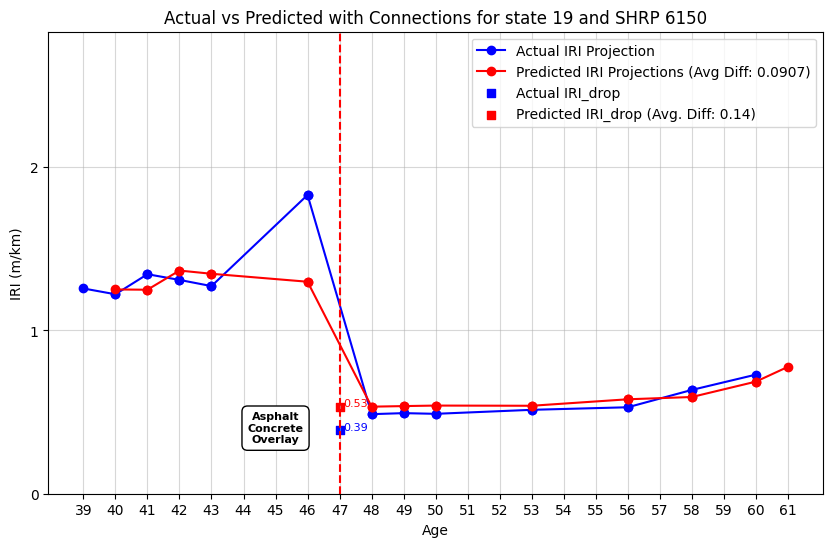